TODO
- filter out patches that still have land in them due to error in halo
- cut ice out of da merge

In [1]:
# Working env variables
jupyterhub = False
smalltest = False

In [2]:
if jupyterhub:
    !pip install ..

In [18]:
import numpy as np
import cmocean
import xgcm
import ecco_v4_py as ecco
import xmitgcm.llcreader as llcreader

import dask.array as da
from dask.distributed import Client

import tqdm

import xarray as xr
import pandas as pd

import uuid
import matplotlib as mpl
import zarr

In [19]:
import dbof.llc4320_ingestion.get_raw_data as get_raw_data
import dbof.preprocessing.preproc_llc_core_data as preproc_llc_core_data
import dbof.dataset_creation.zarr_dataset as zarr_dataset
import dbof.utils.native_gradient as ng
import dbof.utils.physical_calculations as physical_calculations

import dbof.plotting.llc_plotting as llc_plotting

import dbof.dataset_creation.spatial_patches as spatial_patches
import dbof.dataset_creation.metadata as metadata
import dbof.preprocessing.halo_mask as halo_mask

import dbof.preprocessing.native_grid_masks as native_grid_masks



In [3]:
feature_channels = ["Eta", "Salt", "Theta", "U", "V", "W", "log_gradb"]
target_km_res = 150 #km
down_sample_res = 64 #pixels
halo_km = target_km_res #buffer to account for mean usage


In [4]:
timestep_hours = 720 # 4 weeks                     # how many hours to load
sampling_step = 12                      # stride in timesteps
ts_per_hour = 144                       # model cadence: 25 s → 144 steps/hr
iter_step = sampling_step * ts_per_hour # iteration Δ between samples
face_range = range(13)

# NOTE MAX iteration : 1495008

# First valid wind/forcing record begins ~1180
start_record = 1180

# Compute iter numbers
start_iter = 10368 + start_record * ts_per_hour

# end_iter = 1495008 #to the end of data
end_iter = start_iter + timestep_hours * ts_per_hour


iter_range = np.arange(start_iter, end_iter, iter_step)

endpoint_url = 'https://mghp.osn.xsede.org'

In [5]:
dask_client = Client()  # default: uses all local cores
dask_client

Connection method: Cluster object,Cluster type: distributed.LocalCluster
Dashboard: http://127.0.0.1:8787/status,
Dashboard: http://127.0.0.1:8787/status,Workers: 4
Total threads: 12,Total memory: 31.10 GiB
Status: running,Using processes: True
Comm: tcp://127.0.0.1:52133,Workers: 0
Dashboard: http://127.0.0.1:8787/status,Total threads: 0
Started: Just now,Total memory: 0 B
Comm: tcp://127.0.0.1:52158,Total threads: 3
Dashboard: http://127.0.0.1:52161/status,Memory: 7.78 GiB
Nanny: tcp://127.0.0.1:52136,


In [6]:
print(dask_client)

<Client: 'tcp://127.0.0.1:52133' processes=4 threads=12, memory=31.10 GiB>


In [9]:
it = iter_range[0]

co = get_raw_data.get_remote_gridfile(endpoint_url)
ds = get_raw_data.get_remote_llc_data(endpoint_url, it, face_range)

ds_grid = preproc_llc_core_data.process_llc4320_grid(co)
ds_merge = preproc_llc_core_data.process_llc4320(ds, ds_grid)


Opening 13 Kerchunk JSON files...
Parsing JSON metadata into Python dicts...
Creating lazy xarray datasets...
Computing delayed datasets...
Combining datasets by coordinates...
Dataset combined successfully.


In [13]:
# grid = xgcm.Grid(ds_grid, coords={'X':{'center':'XC'}}, periodic=False)
grid = xgcm.Grid(ds_grid, periodic=False)

In [11]:
# llc_plotting.plot_llc_faces_layout( ds_merge.Theta, vmin=-4, vmax=40 )

#Masks

# # first order approximation of freezing point
# #tf = -0.056S - 0.008
# freezing_point_tol = 0.05 #0.05
# agro_freezing_point_tol = 1.0 # ensure we mask ice and some not ice too
#
# ice_mask = ds_merge.Theta <= ((-0.056*ds_merge.Salt) - 0.008 + freezing_point_tol)
#

In [23]:
# land_face_mask = native_grid_masks.generate_static_land_face_masks_for_sampling(ds_grid, 150)

halo_km = 150  # buffer to account for mean usage

DXC = ds_grid["dxC"].persist()
DYC = ds_grid["dyC"].persist()
land_mask = (ds_grid.hFacC == 0).persist()

halo_land_mask = halo_mask.llc_halo_mask(
        mask=land_mask,
        dxC=DXC,
        dyC=DYC,
        halo_km=halo_km
)

faces_perimeter_mask = xr.zeros_like(ds_grid.XC).astype(bool)
faces_perimeter_mask.loc[dict(j=0)] = True
faces_perimeter_mask.loc[dict(j=(faces_perimeter_mask.coords.sizes["j"] - 1))] = True
faces_perimeter_mask.loc[dict(i=0)] = True
faces_perimeter_mask.loc[dict(i=(faces_perimeter_mask.coords.sizes["i"] - 1))] = True

halo_faces_perimeter_mask = halo_mask.llc_halo_mask(
        mask=faces_perimeter_mask,
        dxC=DXC,
        dyC=DYC,
        halo_km=halo_km
)

merged_mask = halo_land_mask & halo_faces_perimeter_mask

In [24]:
ice_mask = ~(ds_merge.Theta <= 0.0)

ice_mask = ice_mask #.values

#merged_mask = ice_mask & land_face_mask
merged_mask = ice_mask & merged_mask

C:\Users\Jake Tallman\PycharmProjects\dbof-in-native-grid\.venv1\Lib\site-packages\distributed\client.py:3370: UserWarning: Sending large graph of size 232.02 MiB.
This may cause some slowdown.
Consider loading the data with Dask directly
 or using futures or delayed objects to embed the data into the graph without repetition.
See also https://docs.dask.org/en/stable/best-practices.html#load-data-with-dask for more information.
  warnings.warn(


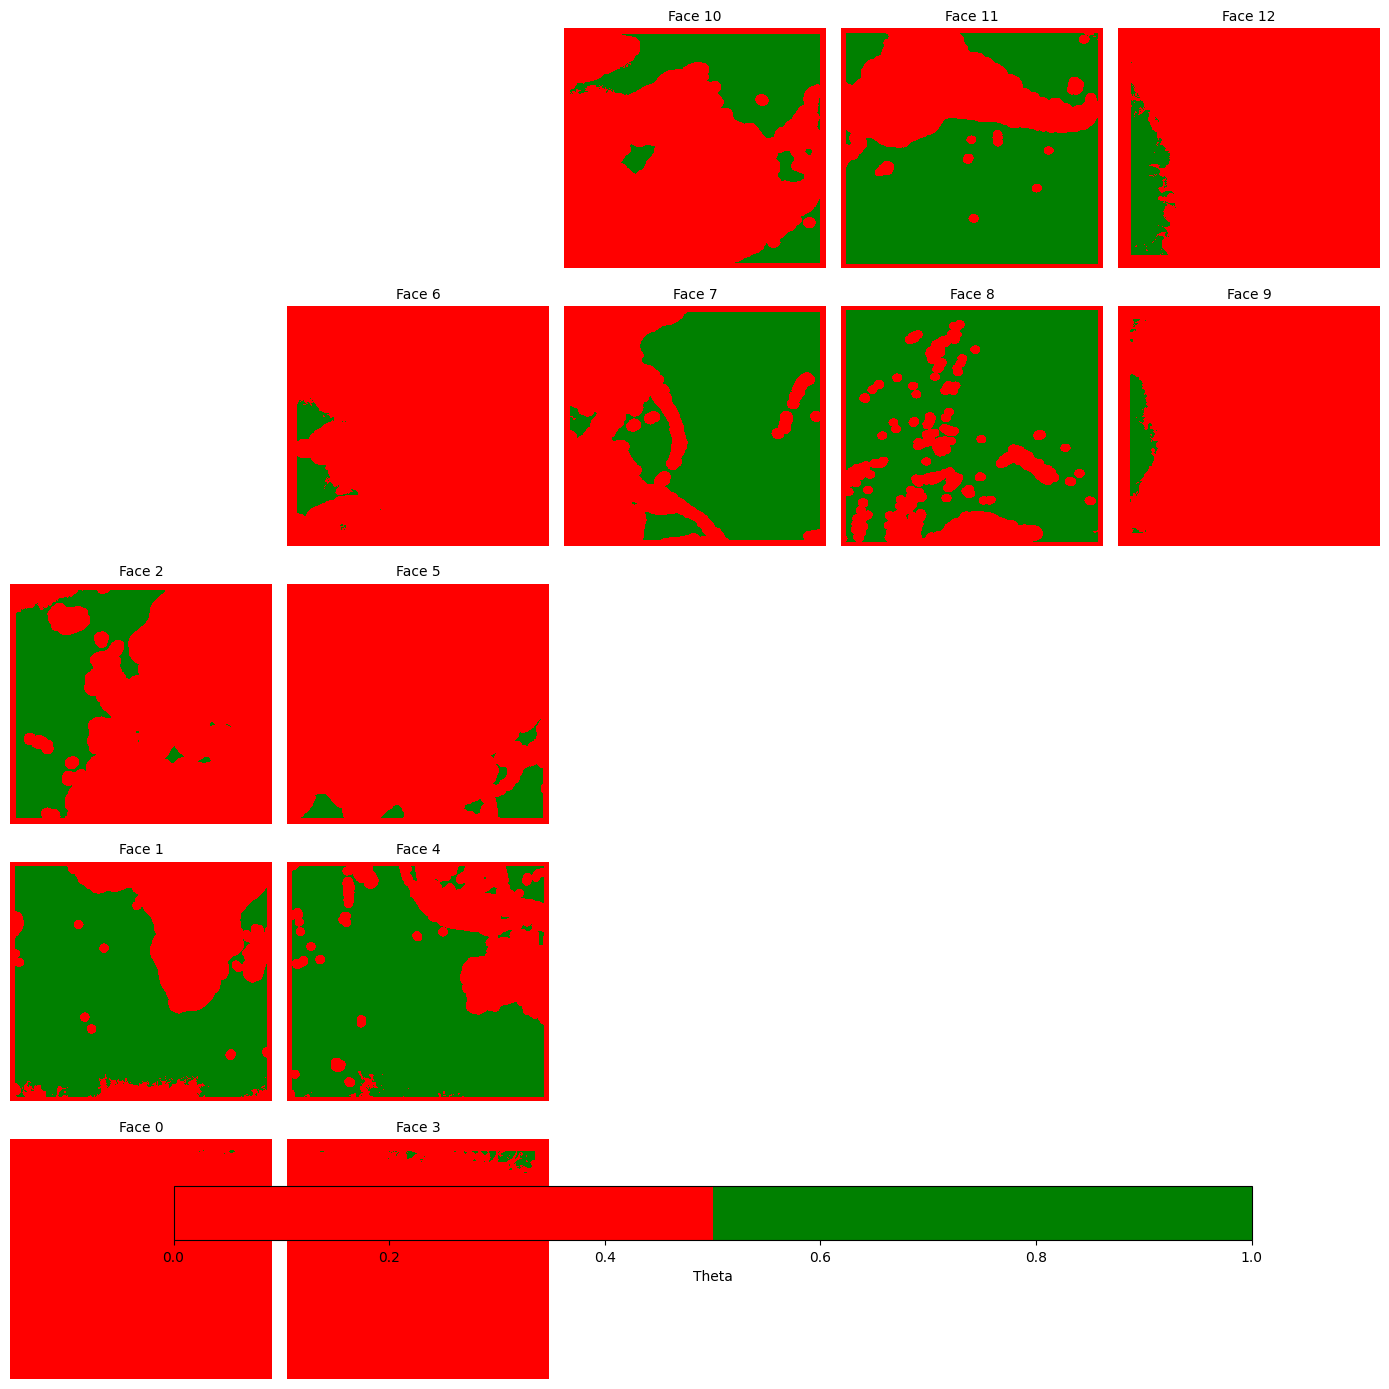

In [28]:
llc_plotting.plot_llc_faces_layout(xr.DataArray(merged_mask), color_map=cmap_bool, is_mask=True, vmin=0, vmax=1)

C:\Users\Jake Tallman\PycharmProjects\dbof-in-native-grid\src\dbof\plotting\llc_plotting.py:151: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


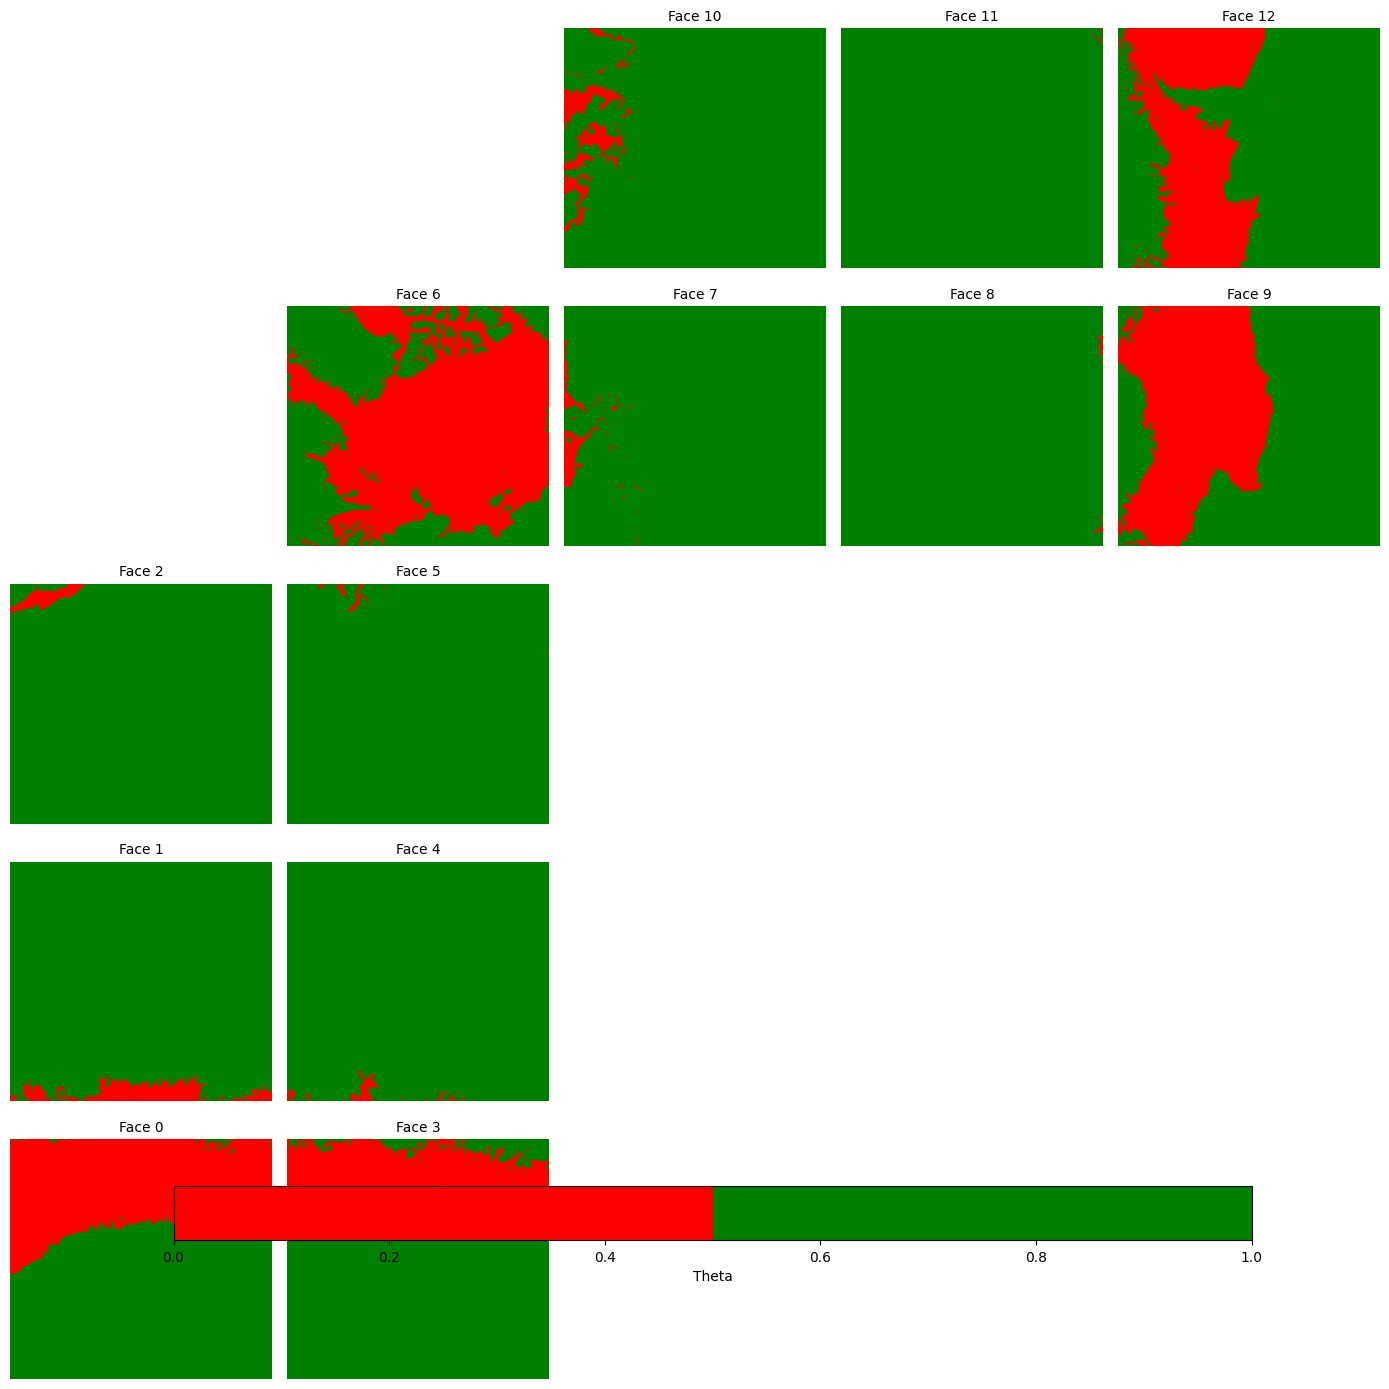

In [25]:
cmap_bool = mpl.colors.ListedColormap(['red', 'green'])

llc_plotting.plot_llc_faces_layout(xr.DataArray(ice_mask), color_map=cmap_bool, is_mask=True, vmin=0, vmax=1)

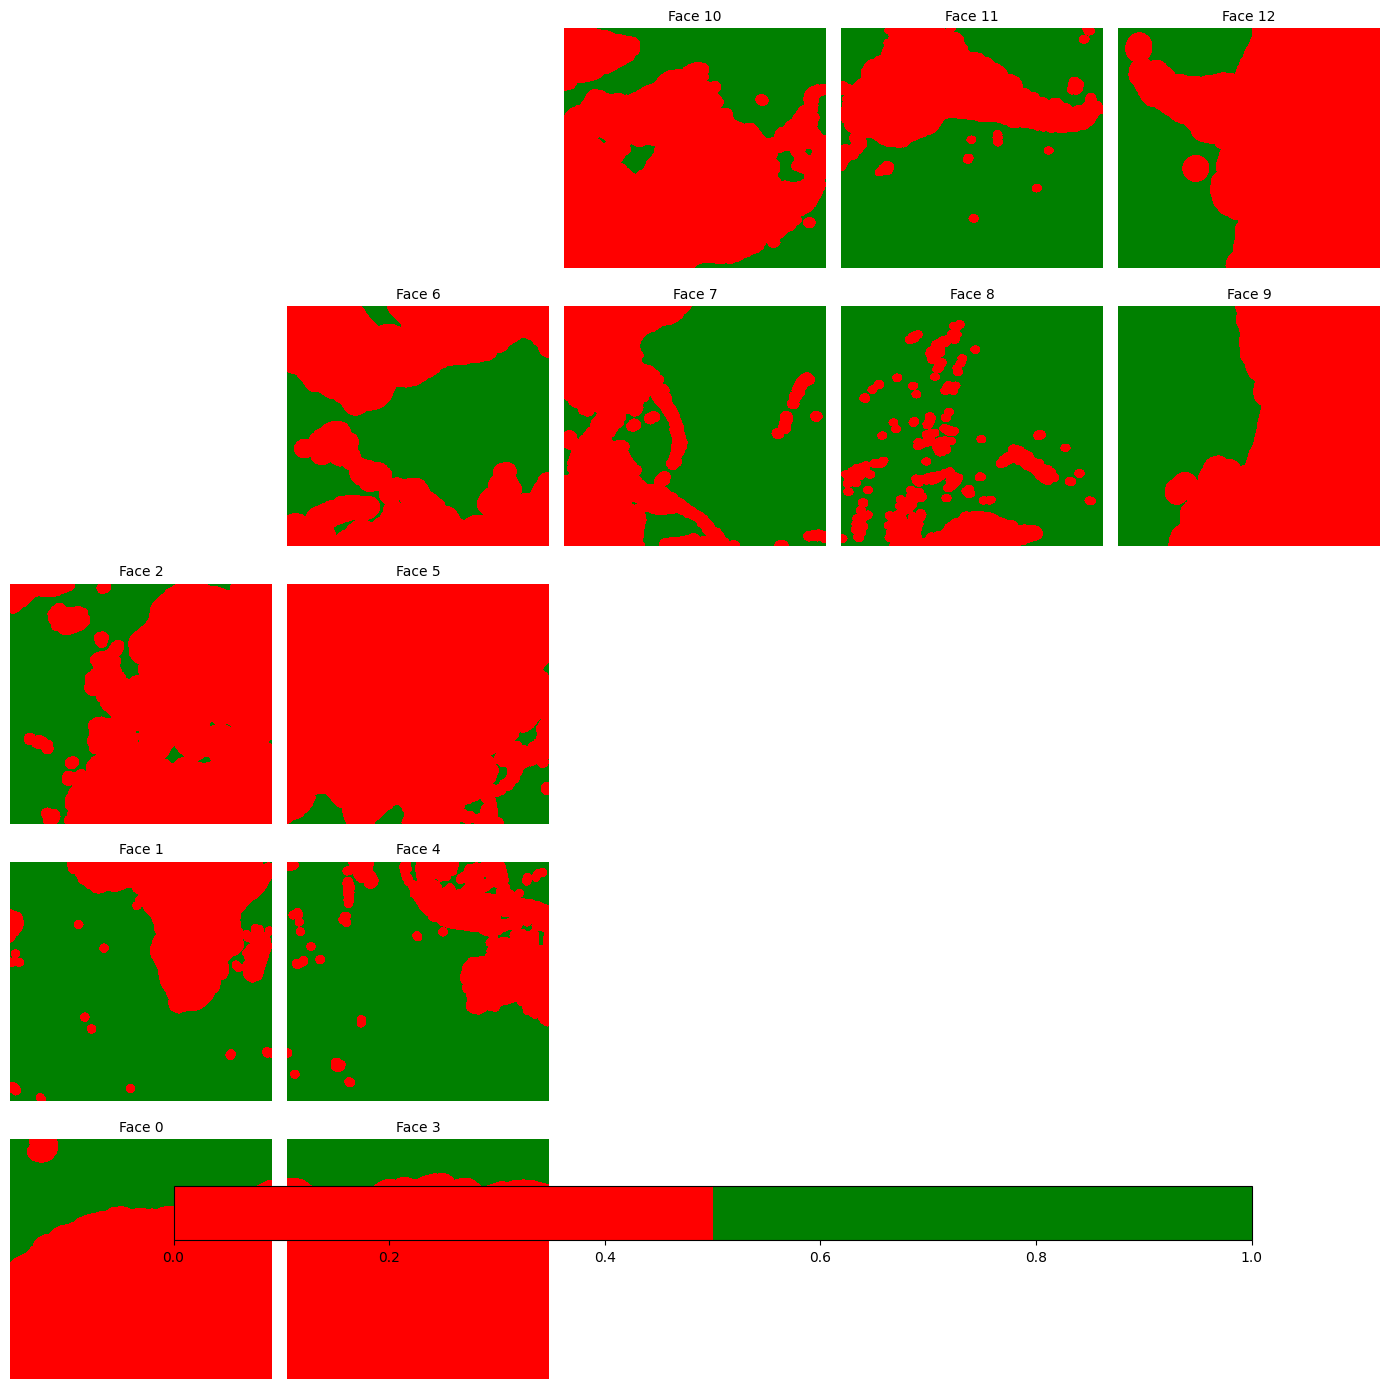

In [26]:
llc_plotting.plot_llc_faces_layout(xr.DataArray(halo_land_mask), color_map=cmap_bool, is_mask=True, vmin=0, vmax=1)

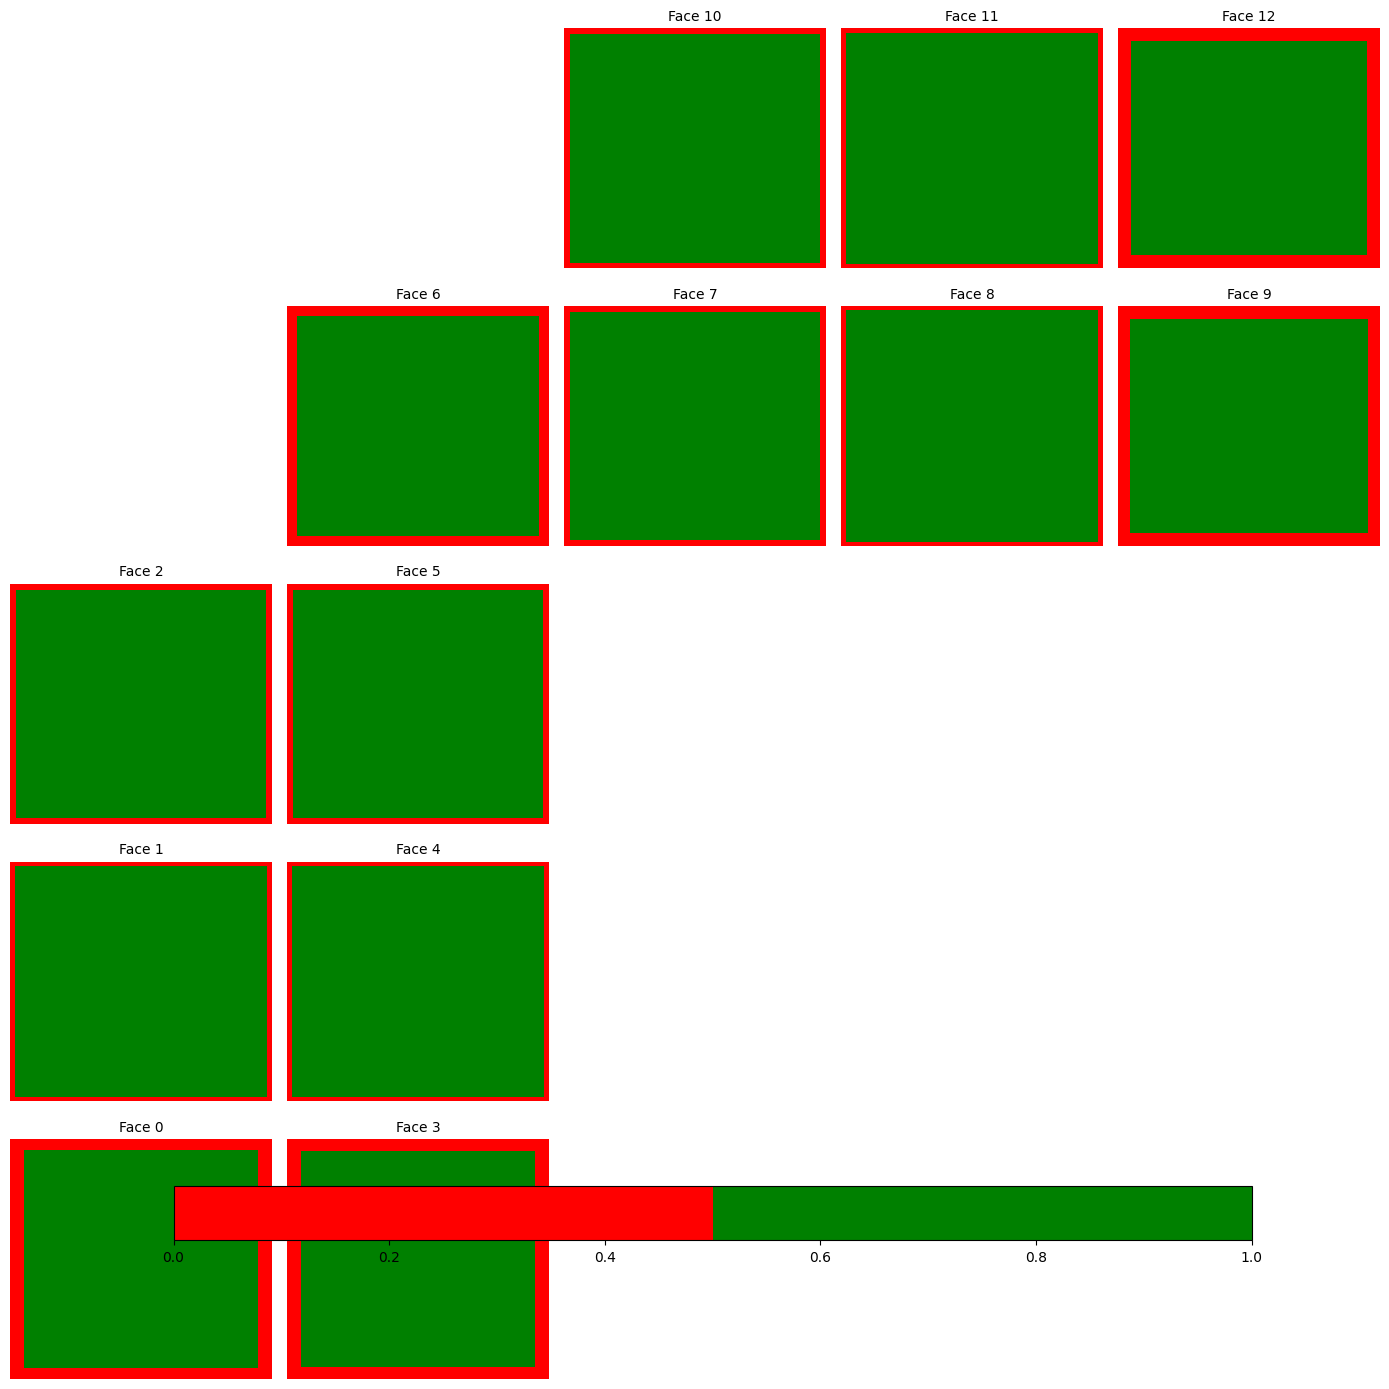

In [27]:
llc_plotting.plot_llc_faces_layout(xr.DataArray(halo_faces_perimeter_mask), color_map=cmap_bool, is_mask=True, vmin=0, vmax=1)

(<Figure size 640x480 with 1 Axes>,
 <GeoAxes: >,
 [],
 array([[-179.975, -179.925, -179.875, ...,  179.875,  179.925,  179.975],
        [-179.975, -179.925, -179.875, ...,  179.875,  179.925,  179.975],
        [-179.975, -179.925, -179.875, ...,  179.875,  179.925,  179.975],
        ...,
        [-179.975, -179.925, -179.875, ...,  179.875,  179.925,  179.975],
        [-179.975, -179.925, -179.875, ...,  179.875,  179.925,  179.975],
        [-179.975, -179.925, -179.875, ...,  179.875,  179.925,  179.975]],
       shape=(3600, 7200)),
 array([[-89.975, -89.975, -89.975, ..., -89.975, -89.975, -89.975],
        [-89.925, -89.925, -89.925, ..., -89.925, -89.925, -89.925],
        [-89.875, -89.875, -89.875, ..., -89.875, -89.875, -89.875],
        ...,
        [ 89.875,  89.875,  89.875, ...,  89.875,  89.875,  89.875],
        [ 89.925,  89.925,  89.925, ...,  89.925,  89.925,  89.925],
        [ 89.975,  89.975,  89.975, ...,  89.975,  89.975,  89.975]],
       shape=(3600, 7200)

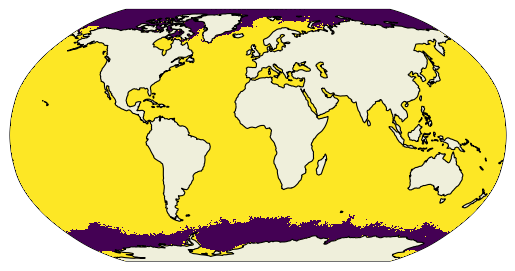

In [17]:
ecco.plot_proj_to_latlon_grid(ds_merge.XC,
                              ds_merge.YC,
                              merged_mask.astype(int),
                              plot_type = 'pcolormesh',
                              dx=0.05,
                              dy=0.05,
                              projection_type = 'robin',
                              less_output = True)

In [22]:
# ecco.plot_proj_to_latlon_grid(ds_merge.XC,
#                               ds_merge.YC,
#                               merged_mask.astype(int),
#                               cmap=cmap_bool,
#                               plot_type = 'pcolormesh',
#                               dx=0.05,
#                               dy=0.05,
#                               projection_type = 'robin',
#                               less_output = True)

In [14]:
buoyancy = physical_calculations.buoyancy_of_field(ds_merge)

# gradient of b
zonal_grad_b, merid_grad_b = ng.calculate_native_gradient_tracer(buoyancy, ds_grid, grid=grid)

# zonal_grad_b = zonal_grad_b.persist()
# merid_grad_b = merid_grad_b.persist()

gradb2 = physical_calculations.grad_squared(zonal_grad_b, merid_grad_b)
# gradb2 = gradb2.persist()


log_gradb = da.log10(gradb2)
# log_gradb.persist()

log_gradb_ds = log_gradb.to_dataset(name="log_gradb")
ds_merge = xr.merge([ds_merge, log_gradb_ds])

ds_merge["log_gradb"] = ds_merge["log_gradb"].persist()

In [21]:
np_arr = log_gradb.values
max = np.nanquantile(np_arr, 0.98)
min = np.nanquantile(np_arr, 0.2)

C:\Users\Jake Tallman\PycharmProjects\dbof-in-native-grid\src\dbof\plotting\llc_plotting.py:151: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


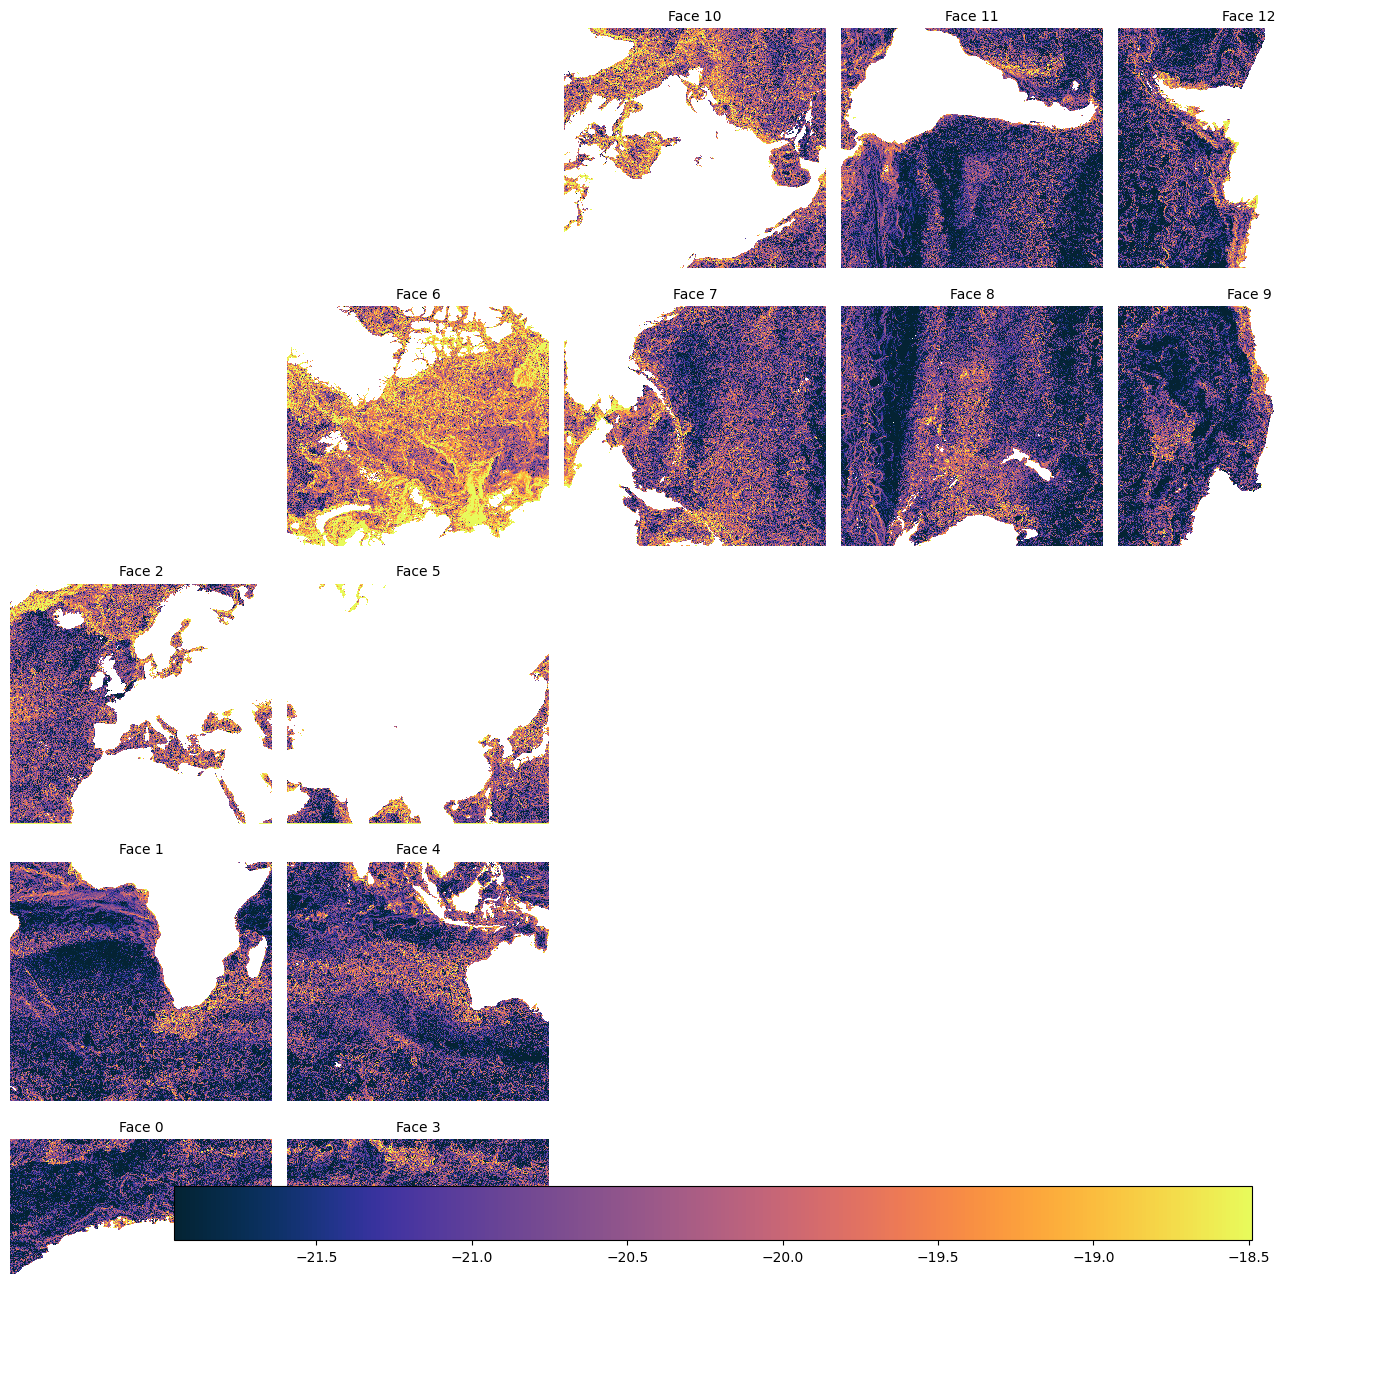

In [22]:
# ecco.plot_proj_to_latlon_grid(ds_merge.XC,
#                               ds_merge.YC,
#                               logvals,
#                               cmap="viridis",
#                               plot_type = 'pcolormesh',
#                               dx=0.25,
#                               dy=0.25,
#                               projection_type = 'robin',
#                               less_output = True,
#                               show_colorbar=True,
#                               cmin=vmin, cmax=vmax)

llc_plotting.plot_llc_faces_layout(xr.DataArray(np_arr), color_map = cmocean.cm.thermal, is_mask=False, vmin=min, vmax=max)

# Sample data points weighted toward high gradient values

## Option 1 : Sample from gradients directly on the grid

This is the best option I believe

slowish

In [18]:
bias_to_high_gradients = 2

SAMPLE_POINTS = 100

if smalltest:
    SAMPLE_POINTS = 50

100%|██████████| 100/100 [01:03<00:00,  1.57it/s]


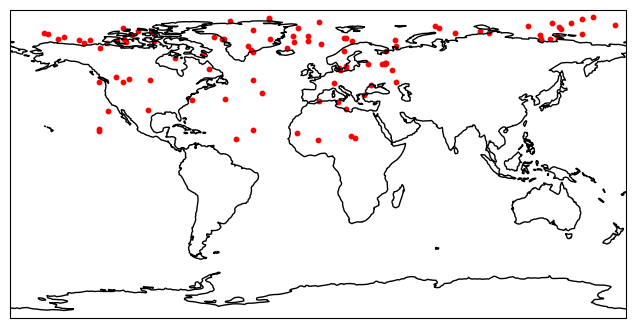

In [21]:
import matplotlib.pyplot as plt
import cartopy.crs as ccrs

print()

lats = []
lons = []
for index in tqdm.tqdm(indices):
    if index is not None:
        lats.append(ds_merge.YC[index].values.item())
        lons.append(ds_merge.XC[index].values.item())

# lats, lons = meta_df["center_lat"], meta_df["center_lon"]

fig = plt.figure(figsize=(8, 4))
ax = plt.axes(projection=ccrs.PlateCarree())

ax.coastlines()
ax.set_global()
ax.scatter(
    lons,
    lats,
    s=10,
    color="red",
    transform=ccrs.PlateCarree()
)

plt.show()

In [43]:
# def weighted_sample_on_grid(points_to_sample, bias, da, stride=None, mask=None):
#     """
#     Draw weighted random samples from an LLC grid based on an input field.
#
#     This function samples grid points with probability proportional to the
#     values of an input xarray DataArray, optionally masked to exclude invalid
#     regions. Higher field values result in higher sampling likelihood. Returned
#     samples are given as native grid indices.
#
#     This function takes a while.
#
#     Parameters
#     ----------
#     points_to_sample : int
#         Number of grid points to sample.
#     bias : float or xarray.DataArray
#         power bias applied to the input field before normalization.
#         Can be a scalar or broadcastable to ``da``.
#     da : xarray.DataArray
#         Input field defined on the LLC grid (e.g., with dimensions
#         ``(face, j, i)``) used to define sampling weights.
#     mask : numpy ndarray or None, optional
#         Boolean mask with the same dimensions as ``da``. Points where
#         ``mask == False`` are excluded from sampling. If None, no masking
#         is applied.
#
#     Returns
#     -------
#     indices : list of tuple
#         List of sampled grid indices as tuples of integers corresponding
#         to ``da.dims`` order (e.g., ``(face, j, i)``).
#
#     Notes
#     -----
#     * Sampling is performed without replacement.
#     * Masked or NaN values are excluded prior to normalization.
#     * Coordinates are preserved through stacking to ensure correct index
#       recovery.
#     """
#
#
#     # --- NEW: stride the grid BEFORE weighting ---
#     if stride is not None:
#         da_s = da.isel(
#             j=slice(None, None, stride),
#             i=slice(None, None, stride),
#         )
#
#         mask = mask.isel(
#             j=slice(None, None, stride),
#             i=slice(None, None, stride),
#         )
#     else :
#         da_s = da
#
#
#     if (mask is not None):
#         da_m = da_s.where(mask)
#
#     weights = np.exp(bias * (da_m - da_m.min(skipna=True)))
#
#     w_stacked = weights.stack(
#         sample_dim=da_m.dims)  # stacks face j i into one dimension but keeps track of indexes
#
#     w_valid = w_stacked.dropna("sample_dim")  # coordinates of xarray are preserved here
#     p = w_valid / w_valid.sum()
#
#     p_np = p.values
#
#     # grab however many samples randomly with higher likelihood for high weights.
#     choice = np.random.choice(
#         p.sample_dim.size,
#         size=points_to_sample,
#         replace=False,
#         p=p_np
#     )
#
#     sampled =  w_valid.isel(sample_dim=choice)
#
#     indices = np.stack(
#         [sampled.coords[dim].values for dim in da_m.dims],
#         axis=1
#     )
#
#     indices = [tuple(row) for row in indices]  # list of tuples containing face j i into our grid
#     indices = [tuple(int(x) for x in t) for t in indices]
#
#     return indices


In [27]:
# import numpy as np
# import xarray as xr
#
#
# def weighted_sample_on_grid_fast(points_to_sample, bias, da, stride=None, mask=None, seed=None):
#     """
#     Draw weighted random samples from an LLC grid using per-face sampling.
#
#     This function is a drop-in replacement for the original
#     ``weighted_sample_on_grid`` but samples independently on each LLC face
#     to reduce memory use and avoid global stacking overhead.
#
#     Sampling within each face is performed without replacement with
#     probability proportional to an exponentially biased version of the
#     input field, matching the original weighting logic.
#
#     Parameters
#     ----------
#     points_to_sample : int
#         Total number of grid points to sample across all faces.
#     bias : float or xarray.DataArray
#         Exponential bias applied to the input field prior to normalization.
#         May be a scalar or broadcastable to ``da``.
#     da : xarray.DataArray
#         Input field defined on the LLC grid with dimensions
#         ``(face, j, i)``.
#     mask : xarray.DataArray or None, optional
#         Boolean mask with the same dimensions as ``da``.
#         Points where ``mask == False`` are excluded from sampling.
#         If None, no masking is applied.
#
#     Returns
#     -------
#     indices : list of tuple
#         List of sampled grid indices as tuples of integers in
#         ``(face, j, i)`` order.
#
#     Notes
#     -----
#     * Sampling is performed without replacement **within each face**.
#     * The total number of samples is approximately distributed evenly
#       across faces with valid data.
#     * Masked or NaN values are excluded prior to normalization.
#     * This implementation avoids global stacking and large coordinate
#       objects, and is significantly faster for large LLC grids.
#     * Sampling probabilities are equivalent to the original method
#       when restricted to each face independently.
#     """
#
#     if mask is not None:
#         if not isinstance(mask, xr.DataArray):
#             raise TypeError("mask must be an xarray.DataArray")
#         da = da.where(mask)
#
#     # --- NEW: stride the grid BEFORE weighting ---
#     if stride is not None:
#         da = da.isel(
#             j=slice(None, None, stride),
#             i=slice(None, None, stride),
#         )
#
#     # Exclude NaNs early
#     da = da.where(np.isfinite(da))
#
#     faces = da.coords["face"].values
#     nface = len(faces)
#
#     # Distribute samples roughly evenly across faces
#     samples_per_face = max(1, points_to_sample // nface)
#
#     indices = []
#
#     for face in faces:
#         da_f = da.sel(face=face)
#
#         if not da_f.notnull().any():
#             continue
#
#         da_min = da_f.min(skipna=True)
#         weights = np.exp(bias * (da_f - da_min))
#
#         # materialize one face only
#         w = weights.data
#         if hasattr(w, "compute"):
#             w = w.compute()
#         w = np.asarray(w) # slow part
#
#         valid = np.isfinite(w)
#         n_valid = valid.sum()
#         if n_valid == 0:
#             continue
#
#         k = min(samples_per_face, n_valid)
#
#         # normalize weights
#         w_valid = w[valid]
#         p = w_valid / w_valid.sum()
#
#         choice = np.random.choice(
#             n_valid,
#             size=k,
#             replace=False,
#             p=p,
#         )
#
#         jj, ii = np.where(valid)
#         for j, i in zip(jj[choice], ii[choice]):
#             indices.append((int(face), int(j), int(i)))
#
#         if len(indices) >= points_to_sample:
#             break
#
#     return indices[:points_to_sample]


In [30]:
# indices = weighted_coordinate_sampling.weighted_sample_on_grid(SAMPLE_POINTS, bias_to_high_gradients, log_gradb, merged_mask)

#original with mask as xarray takes : ~8mins

indices = weighted_sample_on_grid(SAMPLE_POINTS, bias_to_high_gradients, ds_merge["log_gradb"], mask = merged_mask)

C:\Users\Jake Tallman\PycharmProjects\dbof-in-native-grid\.venv1\Lib\site-packages\distributed\client.py:3370: UserWarning: Sending large graph of size 236.35 MiB.
This may cause some slowdown.
Consider loading the data with Dask directly
 or using futures or delayed objects to embed the data into the graph without repetition.
See also https://docs.dask.org/en/stable/best-practices.html#load-data-with-dask for more information.
  warnings.warn(
C:\Users\Jake Tallman\PycharmProjects\dbof-in-native-grid\.venv1\Lib\site-packages\distributed\client.py:3370: UserWarning: Sending large graph of size 520.47 MiB.
This may cause some slowdown.
Consider loading the data with Dask directly
 or using futures or delayed objects to embed the data into the graph without repetition.
See also https://docs.dask.org/en/stable/best-practices.html#load-data-with-dask for more information.
  warnings.warn(


In [44]:
# with ice mask pre computed 4 mins total???
merged_mask_np = merged_mask.values # this takes ~30s here somehow. I dont think it is that fast on the script for some reason

print("Mask done")

indices = weighted_sample_on_grid(SAMPLE_POINTS, bias_to_high_gradients, ds_merge["log_gradb"], mask = merged_mask_np)

Mask done


C:\Users\Jake Tallman\PycharmProjects\dbof-in-native-grid\.venv1\Lib\site-packages\distributed\client.py:3370: UserWarning: Sending large graph of size 235.69 MiB.
This may cause some slowdown.
Consider loading the data with Dask directly
 or using futures or delayed objects to embed the data into the graph without repetition.
See also https://docs.dask.org/en/stable/best-practices.html#load-data-with-dask for more information.
  warnings.warn(
C:\Users\Jake Tallman\PycharmProjects\dbof-in-native-grid\.venv1\Lib\site-packages\distributed\client.py:3370: UserWarning: Sending large graph of size 519.82 MiB.
This may cause some slowdown.
Consider loading the data with Dask directly
 or using futures or delayed objects to embed the data into the graph without repetition.
See also https://docs.dask.org/en/stable/best-practices.html#load-data-with-dask for more information.
  warnings.warn(


In [38]:
# with stride
indices = weighted_sample_on_grid(SAMPLE_POINTS, bias_to_high_gradients, ds_merge["log_gradb"],stride=4, mask=merged_mask)

C:\Users\Jake Tallman\PycharmProjects\dbof-in-native-grid\.venv1\Lib\site-packages\distributed\client.py:3370: UserWarning: Sending large graph of size 237.03 MiB.
This may cause some slowdown.
Consider loading the data with Dask directly
 or using futures or delayed objects to embed the data into the graph without repetition.
See also https://docs.dask.org/en/stable/best-practices.html#load-data-with-dask for more information.
  warnings.warn(
C:\Users\Jake Tallman\PycharmProjects\dbof-in-native-grid\.venv1\Lib\site-packages\distributed\client.py:3370: UserWarning: Sending large graph of size 246.25 MiB.
This may cause some slowdown.
Consider loading the data with Dask directly
 or using futures or delayed objects to embed the data into the graph without repetition.
See also https://docs.dask.org/en/stable/best-practices.html#load-data-with-dask for more information.
  warnings.warn(


In [28]:
indices_f = weighted_sample_on_grid_fast(SAMPLE_POINTS, bias_to_high_gradients, ds_merge["log_gradb"], merged_mask)

C:\Users\Jake Tallman\PycharmProjects\dbof-in-native-grid\.venv1\Lib\site-packages\distributed\client.py:3370: UserWarning: Sending large graph of size 236.02 MiB.
This may cause some slowdown.
Consider loading the data with Dask directly
 or using futures or delayed objects to embed the data into the graph without repetition.
See also https://docs.dask.org/en/stable/best-practices.html#load-data-with-dask for more information.
  warnings.warn(
C:\Users\Jake Tallman\PycharmProjects\dbof-in-native-grid\.venv1\Lib\site-packages\distributed\client.py:3370: UserWarning: Sending large graph of size 236.02 MiB.
This may cause some slowdown.
Consider loading the data with Dask directly
 or using futures or delayed objects to embed the data into the graph without repetition.
See also https://docs.dask.org/en/stable/best-practices.html#load-data-with-dask for more information.
  warnings.warn(
C:\Users\Jake Tallman\PycharmProjects\dbof-in-native-grid\.venv1\Lib\site-packages\distributed\client.

KeyboardInterrupt: 

In [32]:
# # display weights
#
# weights = np.exp(bias_to_high_gradients * (log_gradb - log_gradb.min(skipna=True)))
#
# # weights = log_gradb # - log_gradb.max()
# # weights = np.exp(bias_to_high_gradients * weights)
#
# weights = weights.where(merged_mask)
# # weights = weights.where(~np.isnan(weights))
# p = weights / weights.sum()
#
# # plt.hist(p.values.flatten(), bins=20)
# # plt.yscale("log")
# # plt.show()

In [33]:
# pmin = np.nanquantile(ds_merge.Salt, 0.5)
# pmax = np.nanquantile(ds_merge.Salt, 0.99)

In [34]:
# llc_plotting.plot_llc_faces_layout(da.log10(p), vmin = pmin, vmax = pmax)

In [35]:
# high_cap = np.nanquantile(p.compute(), 0.999)
#
# high_cap_mask = p >= high_cap
# p_high = p.where(high_cap_mask)
#
# ecco.plot_proj_to_latlon_grid(ds_merge.XC,
#                               ds_merge.YC,
#                               p_high,
#                               cmap=cmocean.cm.thermal,
#                               plot_type = 'pcolormesh',
#                               dx=0.05,
#                               dy=0.05,
#                               projection_type = 'robin',
#                               less_output = True)

In [36]:
# smax = 35 #np.nanquantile(ds_merge.Salt, 0.99)
# smin = np.nanquantile(ds_merge.Salt, 0.1)
# print(smin, smax)

In [37]:
# # color bar for salt
# import matplotlib.pyplot as plt
# import matplotlib as mpl
#
# fig, ax = plt.subplots()
#
# cmap = cmocean.cm.haline     # any colormap
# vmin, vmax = 0.0, 1.0      # min / max values
#
# norm = mpl.colors.Normalize(vmin=smin, vmax=smin)
# sm = mpl.cm.ScalarMappable(norm=norm, cmap=cmap)
# sm.set_array([])  # required for older matplotlib
#
# plt.colorbar(sm, ax=ax, label="Value")
# plt.show()


In [38]:
# ecco.plot_proj_to_latlon_grid(ds_merge.XC,
#                               ds_merge.YC,
#                               ds_merge.Salt,
#                               cmap=cmocean.cm.haline,
#                               plot_type = 'pcolormesh',
#                               dx=0.05,
#                               dy=0.05,
#                               projection_type = 'robin',
#                               cmin = smin,
#                               cmax = smax,
#                               less_output = True)

In [39]:
# # filter out highest probability
# log_gradb = log_gradb.where(~high_cap_mask)

## Option 2 Sample from pdf and find matching values in the grid

In [41]:
# x = log_gradb.values  # loads data into memory
#
# samples = weighted_coordinate_sampling.sample_linearly_on_pdf(x, SAMPLE_POINTS, False)
# tolerance = 5e-7
# indices2 = weighted_coordinate_sampling.find_coords_first_parallel(x, samples, tol=tolerance, n_jobs=3) # this uses a lot of ram but is pretty fast

# Generate Spatial Patches from Our Indices

In [21]:
# Move non tracer values to tracer points
# only run this once or weird stuff happens
ds_merge["V"] = grid.interp(ds_merge["V"], 'Y', boundary='fill')
ds_merge["U"] = grid.interp(ds_merge["U"], 'X', boundary='fill')

In [23]:
ds_merge.persist()

<xarray.Dataset> Size: 19GB
Dimensions:    (face: 13, j: 4320, i: 4320, i_g: 4320, j_g: 4320, k_p1: 2,
                k_u: 1)
Coordinates:
  * face       (face) int64 104B 0 1 2 3 4 5 6 7 8 9 10 11 12
  * j          (j) int64 35kB 0 1 2 3 4 5 6 ... 4314 4315 4316 4317 4318 4319
  * i          (i) int64 35kB 0 1 2 3 4 5 6 ... 4314 4315 4316 4317 4318 4319
  * i_g        (i_g) float64 35kB 0.0 1.0 2.0 ... 4.317e+03 4.318e+03 4.319e+03
  * j_g        (j_g) float64 35kB 0.0 1.0 2.0 ... 4.317e+03 4.318e+03 4.319e+03
  * k_p1       (k_p1) float64 16B 0.0 1.0
  * k_u        (k_u) float64 8B 0.0
    k          float64 8B 0.0
    k_l        float64 8B 0.0
    niter      float64 8B dask.array<chunksize=(), meta=np.ndarray>
    time       datetime64[ns] 8B 2011-11-01T04:00:00
Data variables: (12/19)
    Eta        (face, j, i) float32 970MB dask.array<chunksize=(1, 720, 720), meta=np.ndarray>
    Salt       (face, j, i) float32 970MB dask.array<chunksize=(1, 720, 720), meta=np.ndarray>
    Theta      (face, j, i) float32 970MB dask.array<chunksize=(1, 720, 720), meta=np.ndarray>
    U          (face, j, i) float32 970MB dask.array<chunksize=(1, 720, 360), meta=np.ndarray>
    V          (face, j, i) float32 970MB dask.array<chunksize=(1, 360, 720), meta=np.ndarray>
    W          (face, j, i) float32 970MB dask.array<chunksize=(1, 720, 720), meta=np.ndarray>
    ...         ...
    rA         (face, j, i) float32 970MB dask.array<chunksize=(1, 360, 360), meta=np.ndarray>
    Depth      (face, j, i) float32 970MB dask.array<chunksize=(1, 360, 360), meta=np.ndarray>
    hFacC      (face, j, i) float32 970MB dask.array<chunksize=(1, 360, 360), meta=np.ndarray>
    SN         (face, j, i) float32 970MB dask.array<chunksize=(1, 360, 360), meta=np.ndarray>
    CS         (face, j, i) float32 970MB dask.array<chunksize=(1, 360, 360), meta=np.ndarray>
    log_gradb  (face, j, i) float64 2GB dask.array<chunksize=(1, 360, 360), meta=np.ndarray>
Attributes:
    history:  Created by C. Spencer Jones using https://github.com/cspencerjo...
    source:   MITgcm
    title:    Chunked netcdf created from MITgcm LLC4320 surface output

In [24]:
index = (0,0,0)

print(ds_merge.YC[index].compute()) #.values.item()

Task exception was never retrieved
future: <Task finished name='Task-856864' coro=<Client._gather.<locals>.wait() done, defined at C:\Users\Jake Tallman\PycharmProjects\dbof-in-native-grid\.venv1\Lib\site-packages\distributed\client.py:2384> exception=AllExit()>
Traceback (most recent call last):
  File "C:\Users\Jake Tallman\PycharmProjects\dbof-in-native-grid\.venv1\Lib\site-packages\distributed\client.py", line 2393, in wait
    raise AllExit()
distributed.client.AllExit
Task exception was never retrieved
future: <Task finished name='Task-856865' coro=<Client._gather.<locals>.wait() done, defined at C:\Users\Jake Tallman\PycharmProjects\dbof-in-native-grid\.venv1\Lib\site-packages\distributed\client.py:2384> exception=AllExit()>
Traceback (most recent call last):
  File "C:\Users\Jake Tallman\PycharmProjects\dbof-in-native-grid\.venv1\Lib\site-packages\distributed\client.py", line 2393, in wait
    raise AllExit()
distributed.client.AllExit


KeyboardInterrupt: 

In [37]:
# S3 Configuration
bucket = "llc/"
folder = "native_grid_dbof_training_data/"
run_id = "parallel_test/"

s3_endpoint = "https://s3-west.nrp-nautilus.io"

In [38]:
# aws --endpoint https://s3-west.nrp-nautilus.io s3 ls s3://llc/native_grid_dbof_training_data/small_test/metadata/ --human-readable
#
# aws --endpoint https://s3-west.nrp-nautilus.io s3 rm s3://llc/native_grid_dbof_training_data/parallel_test/ --recursive
# --dryrun

In [39]:
# # Make sure you
#
# $env:AWS_ACCESS_KEY_ID="..."
# $env:AWS_SECRET_ACCESS_KEY="..."
#
# or
#
# export AWS_ACCESS_KEY_ID=...
# export AWS_SECRET_ACCESS_KEY=...


In [40]:
import fsspec

# this is for jupyter only to fix asynch loops ---
import nest_asyncio
nest_asyncio.apply()
# -----------------------------


fs = fsspec.filesystem(
    "s3", #
    asynchronous=True,
    client_kwargs={
        "endpoint_url": s3_endpoint,

    },

    # These become botocore.client.Config(...)
    config_kwargs={
        "signature_version": "s3v4",
        "request_checksum_calculation": "when_required",
        "s3": {
            "addressing_style": "path",
            "payload_signing_enabled": False,
            "use_accelerate_endpoint": False,
            "use_dualstack_endpoint": False,
        },
    },
)

fs_synch = fsspec.filesystem(
    "s3", #
    asynchronous=False,
    client_kwargs={
        "endpoint_url": s3_endpoint,

    },

    # These become botocore.client.Config(...)
    config_kwargs={
        "signature_version": "s3v4",
        "request_checksum_calculation": "when_required",
        "s3": {
            "addressing_style": "path",
            "payload_signing_enabled": False,
            "use_accelerate_endpoint": False,
            "use_dualstack_endpoint": False,
        },
    },
)

In [41]:
# import boto3
# from botocore.client import Config
#
# # This Works : todo document
# s3 = boto3.client(
#     "s3",
#     endpoint_url=s3_endpoint,  # outside endpoint
#     config=Config(
#         s3={
#             "addressing_style": "path",     # MUST be path-style
#             "signature_version":"s3v4",
#             "multipart_threshold": "1GB",
#             "multipart_chunksize" : "256MB",
#             "max_bandwidth" : "200MB/s",
#             "use_accelerate_endpoint" : False,
#             "use_dualstack_endpoint" : False,
#             "when_required " : False,
#         },
#         request_checksum_calculation = "when_required",
#         signature_version="s3v4"
#     )
# )

In [42]:
# These tests will not work with the asynch filesystem
# with open('test.txt', 'rb') as f:
#     data = f.read()
#     s3.put_object(Bucket='llc', Key=f"{folder}{run_id}test2.txt", Body=data)


# with fs.open(bucket+folder+run_id+"testAs.txt", "wb") as f:  # "wb" = write bytes
#     f.write(b"hello")
# s3.list_objects(Bucket="llc")


In [43]:
# # store = zarr.open_group(dataset_path, mode="a")
#
# store = zarr.storage.FsspecStore(
#     path=bucket+folder+run_id+"dataset_creation.zarr",
#     fs=fs
# )
#
# root = zarr.open_group(store=store, mode="a")
#
# print(root)
#
# C, H, W = len(feature_channels), down_sample_res, down_sample_res

# if "images" not in root:
#     root.create_array(
#         "images",
#         shape=(0, C, H, W),
#         chunks=(1, C, H, W),
#         dtype="float32"
#     )

# def append_image(zstore, img): # todo batch? and make this a class
#     zstore["images"].append(np.expand_dims(img, axis=0), axis=0)
#     n = zstore["images"].shape[0]
#     return n   # zarr index
#


In [44]:
# set up metadata

# meda_data_file_path = "s3://" + bucket + folder + run_id + "metadata/metadata.parquet"

metadata_cols = [
    "id",
    "dataset_index",
    "native_grid",
    "center_grid_face",
    "center_grid_j",
    "center_grid_i",
    "center_lat",
    "center_lon",
    "target_km_res",
    "real_km_w",
    "real_km_h",
    "pre_interp_res",
    "log_grad_b_2_center",
    "time_snapshot"
]

# fs = s3fs.S3FileSystem(
#     client_kwargs={
#         "endpoint_url": s3_endpoint,
#     },
#     config_kwargs={
#         "s3": {"addressing_style": "path"},
#     },
# )




# metadata_writer = metadata.MetadataWriter(meda_data_file_path, flush_every=10000, fs = fs_synch)

In [45]:
# concurrency
zarr.config.set({'async.concurrency': 128})

In [46]:
# def worker_task(zarr_ds, metadata_writer, worker_id, feature_channels, down_sample_res,
#                 indices, ds_merge, target_km_res, metadata_cols):
#
#     for index in tqdm.tqdm(indices, desc=f"Worker {worker_id}"):
#
#         index = tuple(index)
#         if (index is None):
#             continue
#
#         patch_metadata = dict.fromkeys(metadata_cols)
#         patch_metadata["id"] = str(uuid.uuid4())
#         patch_metadata["native_grid"] = "LLC4320" # todo all supported for now
#         patch_metadata["center_grid_face"] = index[0]
#         patch_metadata["center_grid_j"] = index[1]
#         patch_metadata["center_grid_i"] = index[2]
#         patch_metadata["target_km_res"] = target_km_res
#         patch_metadata["center_lat"] = ds_merge.YC[index].values.item()
#         patch_metadata["center_lon"] = ds_merge.XC[index].values.item()
#         patch_metadata["log_grad_b_2_center"] = (ds_merge.log_gradb[index].values.item())
#         patch_metadata["time_snapshot"] = np.datetime64(ds_merge.time.item(), 'ns')
#
#         patch = spatial_patches.get_lat_lon_extents_of_patch(index, ds_merge, target_km_res)
#
#         if(patch is None):
#             print(f"Skipping index {index}")
#             continue
#
#         patch_metadata["real_km_w"] = patch["real_km_w"]
#         patch_metadata["real_km_h"] = patch["real_km_h"]
#
#         img_patch = spatial_patches.create_image_patch(ds_merge, feature_channels, patch)
#
#         patch_metadata["pre_interp_res"] = img_patch[0].shape
#         data_sample = spatial_patches.downsample_image(img_patch, target_dim=down_sample_res)
#
#         # add data to zarr
#         image_id = zarr_ds.append_image(data_sample)
#         patch_metadata["dataset_index"] = image_id
#
#         # add metadata
#         metadata_writer.add(patch_metadata)
#
#     metadata_writer.close()

In [50]:
# from concurrent.futures import ThreadPoolExecutor
#
# def run_parallel(zarr_ds, metadata_writer, feature_channels, down_sample_res,
#                  indices, ds_merge, target_km_res, metadata_cols,
#                  num_workers):
#
#     # split indices evenly among workers
#     indices_split = np.array_split(indices, num_workers)
#
#     with ThreadPoolExecutor(max_workers=num_workers) as executor:
#         futures = []
#         for wid in range(num_workers):
#             futures.append(
#                 executor.submit(
#                     worker_task,
#                     zarr_ds, metadata_writer,
#                     wid, feature_channels, down_sample_res,
#                     indices_split[wid], ds_merge,
#                     target_km_res, metadata_cols
#                 )
#             )
#         # wait for all workers to finish
#         for f in futures:
#             f.result()

In [52]:
from concurrent.futures import ThreadPoolExecutor
def worker_task(zarr_ds, metadata_writer, worker_id, down_sample_res,
                indices, ds_merge, target_km_res):
    """
    Process a subset of sampled grid indices and write patches + metadata.

    Each worker:
      - extracts spatial patches
      - downsamples to target resolution
      - appends image data to the Zarr dataset_creation
      - records per-patch metadata

    Parameters
    ----------
    zarr_ds : ZarrDataset
        Thread-safe Zarr dataset_creation writer.
    metadata_writer : MetadataWriter
        Thread-safe metadata writer.
    worker_id : int
        Worker identifier (for debugging) todo.
    down_sample_res : int
        Output spatial resolution in pixels.
    indices : iterable
        Iterable of (face, j, i) grid indices. Center points of our patches.
    ds_merge : xarray.Dataset
        Dataset containing fields and gradients.
    target_km_res : float
        Target physical resolution in km.
    """

    for index in indices:

        index = tuple(index)
        if (index is None):
            continue

        patch_metadata = dict.fromkeys(metadata_cols)
        patch_metadata["id"] = str(uuid.uuid4())
        patch_metadata["native_grid"] = "LLC4320" # todo all supported for now
        patch_metadata["center_grid_face"] = index[0]
        patch_metadata["center_grid_j"] = index[1]
        patch_metadata["center_grid_i"] = index[2]
        patch_metadata["target_km_res"] = target_km_res

        # FOR NOW TODO
        # patch_metadata["center_lat"] = ds_merge.YC[index].values.item()
        # patch_metadata["center_lon"] = ds_merge.XC[index].values.item()
        # patch_metadata["log_grad_b_2_center"] = (ds_merge.log_gradb[index].values.item())
        # patch_metadata["time_snapshot"] = np.datetime64(ds_merge.time.item(), 'ns')

        patch = spatial_patches.get_lat_lon_extents_of_patch(index, ds_merge, target_km_res)

        if(patch is None):
            continue

        patch_metadata["real_km_w"] = patch["real_km_w"]
        patch_metadata["real_km_h"] = patch["real_km_h"]

        img_patch = spatial_patches.create_image_patch(ds_merge, feature_channels, patch)

        patch_metadata["pre_interp_res"] = img_patch[0].shape
        data_sample = spatial_patches.downsample_image(img_patch, target_dim=down_sample_res)

        # add data to zarr
        image_id = zarr_ds.append_image(data_sample)
        patch_metadata["dataset_index"] = image_id

        # add metadata
        metadata_writer.add(patch_metadata)

def run_parallel_patch_creation(zarr_ds, metadata_writer, down_sample_res,
                 indices, ds_merge, target_km_res, num_workers):
    """
    Parallelize patch extraction and writing across worker threads.

    Parameters
    ----------
    zarr_ds : ZarrDataset
        Shared Zarr dataset_creation writer.
    metadata_writer : MetadataWriter
        Shared metadata writer.
    down_sample_res : int
        Output resolution in pixels.
    indices : array-like
        Sampled grid indices to process.
    ds_merge : xarray.Dataset
        Dataset containing data fields.
    target_km_res : float
        Target physical resolution.
    num_workers : int
        Number of worker threads.
    """

    # split indices evenly among workers
    num_workers = min(num_workers, len(indices)) # ensure no empty splits
    indices_split = np.array_split(indices, num_workers)

    print(f"Starting parallel patch creation with {num_workers} workers")

    with ThreadPoolExecutor(max_workers=num_workers) as executor:
        futures = []
        for wid in range(num_workers):
            futures.append(
                executor.submit(
                    worker_task,
                    zarr_ds, metadata_writer,
                    wid, down_sample_res,
                    indices_split[wid], ds_merge,
                    target_km_res
                )
            )
        # wait for all workers to finish
        for f in futures:
            f.result()

    metadata_writer.close()

    print(f"Finished parallel patch creation of {len(indices)} indices with {num_workers} workers")

In [59]:
dask_client.close()

In [53]:
num_workers = 25

# Create zarr dataset_creation and metadata
dataset_name = f"dataset_creation.zarr"
zarr_ds = zarr_dataset.ZarrDataset(bucket, folder, run_id, dataset_name, fs=fs,
                                   feature_channels=feature_channels,
                                   down_sample_res=down_sample_res)
# grow ds
zarr_ds.grow_array(len(indices))

meda_data_folder_path = "s3://" + bucket + folder + run_id + f"metadata/"
metadata_writer = metadata.MetadataWriter(meda_data_folder_path, flush_every=10, fs = fs_synch)

ds_merge.persist()
run_parallel_patch_creation(zarr_ds, metadata_writer, down_sample_res,
                 indices, ds_merge, target_km_res,
                 num_workers)

C:\Users\Jake Tallman\PycharmProjects\dbof-in-native-grid\.venv1\Lib\site-packages\zarr\core\dtype\npy\string.py:249: UnstableSpecificationWarning: The data type (FixedLengthUTF32(length=32, endianness='little')) does not have a Zarr V3 specification. That means that the representation of arrays saved with this data type may change without warning in a future version of Zarr Python. Arrays stored with this data type may be unreadable by other Zarr libraries. Use this data type at your own risk! Check https://github.com/zarr-developers/zarr-extensions/tree/main/data-types for the status of data type specifications for Zarr V3.
  v3_unstable_dtype_warning(self)


Starting parallel patch creation with 25 workers
HIT FACE
STARTING i INDICES IS LESS THAN ZERO AND THEREFORE OFF THE FACE OR DATA
HIT FACE64
STARTING j INDEX IS LESS THAN ZERO AND THEREFORE OFF THE FACE OR DATA
HIT FACE5
STARTING j INDEX IS LESS THAN ZERO AND THEREFORE OFF THE FACE OR DATA
HIT FACE
HIT FACE
HIT FACE
STARTING i INDICES IS LESS THAN ZERO AND THEREFORE OFF THE FACE OR DATA
ENDING j INDICES IS GREATER THAN END OF FACE AND THEREFORE OFF THE FACE OR DATA
STARTING i INDICES IS LESS THAN ZERO AND THEREFORE OFF THE FACE OR DATA
HIT FACE92
STARTING j INDEX IS LESS THAN ZERO AND THEREFORE OFF THE FACE OR DATA
HIT FACE
ENDING j INDICES IS GREATER THAN END OF FACE AND THEREFORE OFF THE FACE OR DATA
Finished parallel patch creation of 100 indices with 25 workers


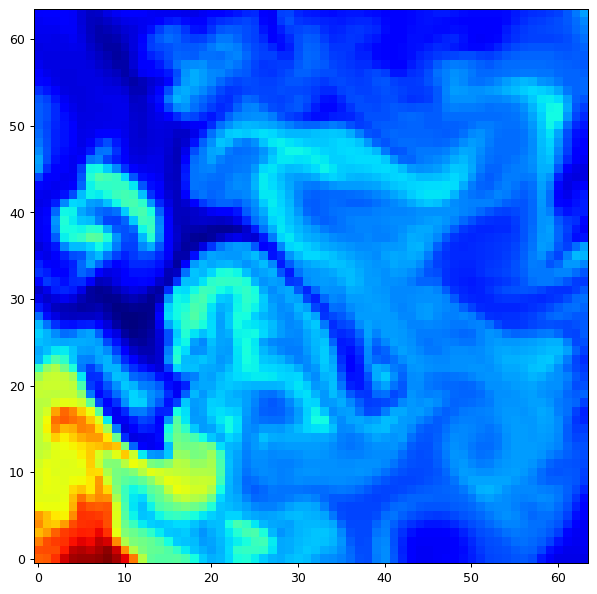

In [65]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,8), dpi= 90)
plt.imshow(zarr_ds.root["images"][1][1],origin='lower',cmap='jet')

In [66]:


files = fs_synch.glob(
    "llc/native_grid_dbof_training_data/parallel_test/metadata/*.parquet"
)

In [68]:
files

['llc/native_grid_dbof_training_data/parallel_test/metadata/part-021ca7bae6194da5b69de9efc36e432f.parquet',
 'llc/native_grid_dbof_training_data/parallel_test/metadata/part-06420fd61a7d42828128ff209ec58ea5.parquet',
 'llc/native_grid_dbof_training_data/parallel_test/metadata/part-0ba076f51d0345babe153ce62e7976f4.parquet',
 'llc/native_grid_dbof_training_data/parallel_test/metadata/part-0d311431cfe64edbaf4545a11343fde6.parquet',
 'llc/native_grid_dbof_training_data/parallel_test/metadata/part-0df8f72e6aeb4a7bbe5cb5660fa26de4.parquet',
 'llc/native_grid_dbof_training_data/parallel_test/metadata/part-0e04cd21e0f84b5aa96b0dfca5806a96.parquet',
 'llc/native_grid_dbof_training_data/parallel_test/metadata/part-0f8238d630734c9db9282c1bada90e96.parquet',
 'llc/native_grid_dbof_training_data/parallel_test/metadata/part-16559663cafd40389d059ecd00ce1141.parquet',
 'llc/native_grid_dbof_training_data/parallel_test/metadata/part-1bb7bce95c1d40388c52c437768d2850.parquet',
 'llc/native_grid_dbof_train

In [67]:
meta_df = pd.read_parquet(files, filesystem=fs_synch)

In [69]:
meta_df

,id,dataset_index,native_grid,center_grid_face,center_grid_j,center_grid_i,center_lat,center_lon,target_km_res,real_km_w,real_km_h,pre_interp_res,log_grad_b_2_center,time_snapshot
0,b564696c-f5d4-46eb-95c8-dd663b13e6f8,561c1b25de4e41ca95f0bb99ccbb9889,LLC4320,12,2091,1921,-73.220039,-84.913269,150,149.534970,149.050215,"[225, 207]",-17.881093,2011-11-01 04:00:00
1,5ae120e3-dd64-49fe-a0bb-a282286cc19f,d1a5ab334c2144c2829f6174188b472f,LLC4320,12,1258,2295,-74.886406,-102.650764,150,149.447104,149.437431,"[263, 254]",-16.371806,2011-11-01 04:00:00
2,35da2d45-1258-49ad-bebb-1cbe099f65a9,4cb44973560143dd9875c8af793c0bf5,LLC4320,2,1979,4091,46.001423,47.239582,150,148.021048,148.812400,"[100, 93]",-18.882673,2011-11-01 04:00:00
3,75788377-5df5-4e0c-994d-d2614c8e8321,34456178f9ff4b6dab2932b9c5a42b4f,LLC4320,6,3593,2458,78.329887,-94.466705,150,149.535290,149.703916,"[158, 175]",-19.567487,2011-11-01 04:00:00
4,8fb766ad-bf90-4971-839b-f77683c51471,03ba37f40cac4457aa0618fe2684420b,LLC4320,6,2351,102,72.909454,1.762820,150,148.437842,149.921263,"[169, 148]",-18.501680,2011-11-01 04:00:00
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
86,4a3a1d08-4f07-44f7-a4da-f3eb6746babc,a3a44abc7abb41f0b6b15ab744a08d54,LLC4320,6,3870,2011,76.072960,-78.177361,150,149.324625,148.946171,"[151, 173]",-18.427081,2011-11-01 04:00:00
87,d654f6b5-27f3-4675-a818-838f45a2e2b3,a4d9bcd77aed4b8ea73826bfa39a34c6,LLC4320,10,3985,1484,56.510071,-44.968750,150,148.274527,148.254429,"[117, 123]",-18.939991,2011-11-01 04:00:00
88,d549bdad-f9f8-4c0a-af54-89b954030146,9ec47620dcbd4a7785ae4c9af8beb122,LLC4320,11,2258,769,-0.958062,-80.947914,150,146.246431,148.215906,"[65, 69]",-17.573922,2011-11-01 04:00:00
89,f36ed608-c345-457d-8ff5-2795498faec6,6255ce523dff4c7e9ed6e1b6c6787e53,LLC4320,8,2386,1923,-22.533041,-168.281250,150,149.464284,149.756301,"[71, 77]",-19.102906,2011-11-01 04:00:00


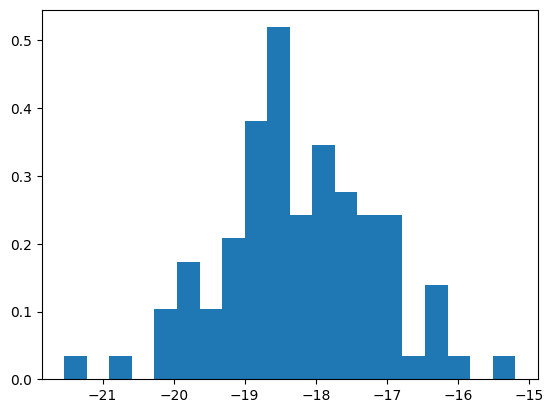

In [70]:
hist, edges = np.histogram(meta_df["log_grad_b_2_center"], bins=20, density=True)

plt.bar(
    edges[:-1],
    hist,
    width=np.diff(edges),
    align="edge"
)

plt.show()

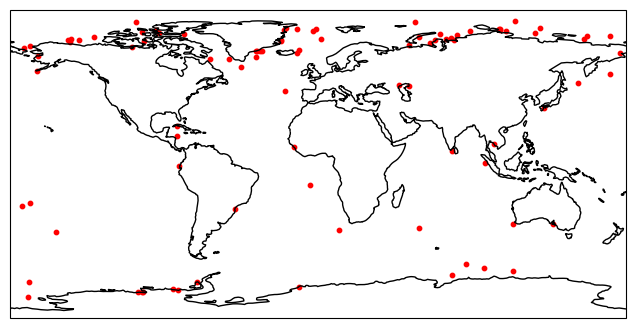

In [71]:
import matplotlib.pyplot as plt
import cartopy.crs as ccrs

lats, lons = meta_df["center_lat"], meta_df["center_lon"]

fig = plt.figure(figsize=(8, 4))
ax = plt.axes(projection=ccrs.PlateCarree())

ax.coastlines()
ax.set_global()
ax.scatter(
    lons,
    lats,
    s=10,
    color="red",
    transform=ccrs.PlateCarree()
)

plt.show()

In [71]:
# # ---- Post-processing ----
# def concatenate_metadata(bucket, folder, run_id, num_workers):
#     dfs = []
#     for wid in range(num_workers):
#
#         meda_data_file_path =  "s3://" + bucket + folder + run_id + "metadata/metadata_{worker_id}.parquet"
#         meta_df = pd.read_parquet(meda_data_file_path, filesystem=fs_synch)
#         dfs.append(meta_df)
#
#     return pd.concat(dfs, ignore_index=True)
#
#
# def get_worker_zarr_arrays(bucket, folder, run_id, num_workers, fs):
#     import zarr
#     arrays = []
#     for wid in range(num_workers):
#         dataset_name = f"{bucket}{folder}{run_id}dataset_{wid}.zarr"
#         store = zarr.storage.FsspecStore(path=dataset_name, fs=fs)
#         arr = zarr.open_group(store, mode="r")
#         arrays.append(arr)
#
#
#     return arrays

In [72]:
# datasets = get_worker_zarr_arrays(bucket, folder, run_id, num_workers, fs)

In [56]:
# patches = []
# print()
# # this is our main loop of data dataset_creation
# # todo parallelize obviously
# for index in tqdm.tqdm(indices):
#     if index is not None:
#         patch_metadata = dict.fromkeys(metadata_cols)
#         patch_metadata["id"] = str(uuid.uuid4())
#         patch_metadata["native_grid"] = "LLC4320" # todo all supported for now
#         patch_metadata["center_grid_face"] = index[0]
#         patch_metadata["center_grid_j"] = index[1]
#         patch_metadata["center_grid_i"] = index[2]
#         patch_metadata["target_km_res"] = target_km_res
#         patch_metadata["center_lat"] = ds_merge.YC[index].values.item()
#         patch_metadata["center_lon"] = ds_merge.XC[index].values.item()
#         patch_metadata["log_grad_b_2_center"] = (ds_merge.log_gradb[index].values.item())
#         patch_metadata["time_snapshot"] = np.datetime64(ds_merge.time.item(), 'ns')
#
#         patch = spatial_patches.get_lat_lon_extents_of_patch(index, ds_merge, target_km_res)
#
#         if(patch is None):
#             print(indices)
#             continue # todo we should log this somehow
#
#         patches.append(patch)
#
#         patch_metadata["real_km_w"] = patch["real_km_w"]
#         patch_metadata["real_km_h"] = patch["real_km_h"]
#
#         patch_img = ds_merge.Theta.isel(
#             face=patch["face"],
#             j=slice(patch["j_start"], patch["j_end"] + 1),
#             i=slice(patch["i_start"], patch["i_end"] + 1)
#         )
#         patch_metadata["pre_interp_res"] = patch_img.shape
#         img_patch = spatial_patches.create_image_patch(ds_merge, feature_channels, patch)
#         data_sample = spatial_patches.downsample_image(img_patch)
#
#         # add data to zarr
#         idx = append_image(root, data_sample)
#         patch_metadata["dataset_index"] = idx
#
#
#         # add metadata
#         metadata_writer.add(patch_metadata)
#
# metadata_writer.close()

In [ ]:
# # polar point
# latlon_dict = get_lat_lon_extents_of_patch((6, 2159, 2159), log_gradb, ds_merge, 150)
#
# #print(latlon_dict["lat_min"], latlon_dict["lat_max"], latlon_dict["lon_min"], latlon_dict["lon_max"])

In [ ]:
# # worst possible point for dx dy ratio 3 0 623
# latlon_dict = get_lat_lon_extents_of_patch((3, 700, 1023), log_gradb, ds_merge, 150)

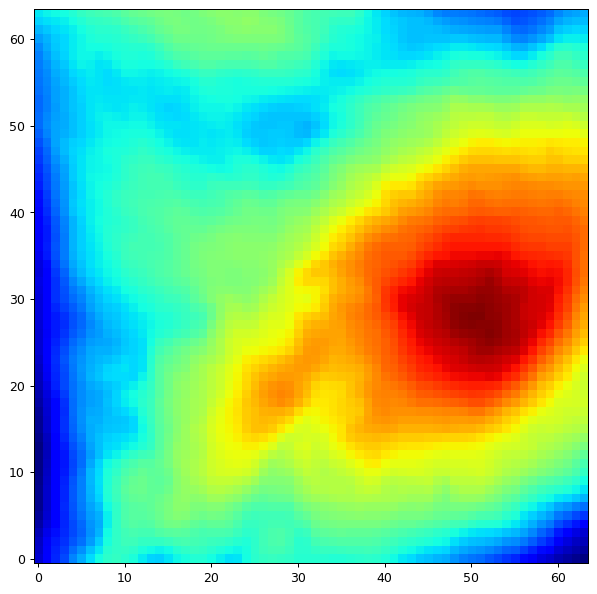

In [55]:
plt.figure(figsize=(8,8), dpi= 90)
plt.imshow(root["images"][5][0],origin='lower',cmap='jet')

(159, 143)
(71, 77)
(89, 95)
(89, 97)
(71, 77)
(129, 126)
(67, 71)
(113, 107)
(81, 88)
(123, 138)
(87, 94)
(93, 100)
(85, 92)
(127, 138)
(101, 107)
(115, 120)
(91, 97)
(67, 73)
(171, 149)
(65, 71)
(119, 127)


/tmp/ipykernel_4247/3348171623.py:20: RuntimeWarning: More than 20 figures have been opened. Figures created through the pyplot interface (`matplotlib.pyplot.figure`) are retained until explicitly closed and may consume too much memory. (To control this warning, see the rcParam `figure.max_open_warning`). Consider using `matplotlib.pyplot.close()`.
  plt.figure(figsize=(8,8), dpi= 90)


(173, 161)
(91, 97)
(73, 79)
(111, 116)
(65, 71)
(75, 81)
(115, 120)
(71, 77)
(85, 92)
(101, 108)
(137, 140)
(73, 79)
(159, 144)
(107, 112)
(140, 151)
(186, 170)
(125, 114)
(99, 105)
(87, 93)
(173, 152)
(89, 95)
(123, 136)
(87, 94)
(85, 92)
(65, 71)
(71, 77)
(67, 73)
(99, 105)
(87, 93)
(91, 97)
(143, 144)
(150, 161)
(95, 102)
(119, 124)
(71, 77)
(119, 129)
(148, 159)
(81, 87)
(171, 148)
(86, 79)
(113, 107)
(79, 73)
(88, 81)
(93, 99)
(75, 69)
(161, 146)
(123, 127)
(97, 104)
(121, 135)
(74, 69)
(121, 126)
(84, 77)
(173, 160)
(117, 122)
(75, 81)
(73, 79)
(111, 116)
(69, 75)
(111, 116)
(105, 110)
(67, 74)
(90, 83)
(77, 71)
(73, 79)
(75, 81)
(73, 80)
(95, 101)
(171, 148)
(71, 65)
(89, 83)
(75, 69)
(91, 83)
(73, 79)
(119, 115)
(127, 128)
(65, 71)
(121, 132)
(171, 149)
(109, 115)


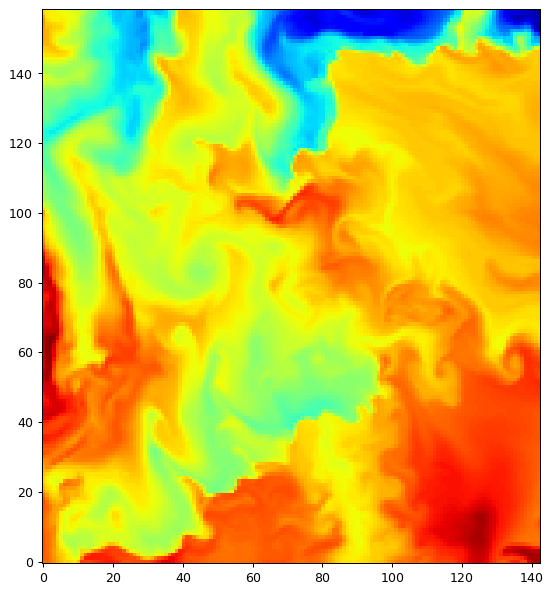

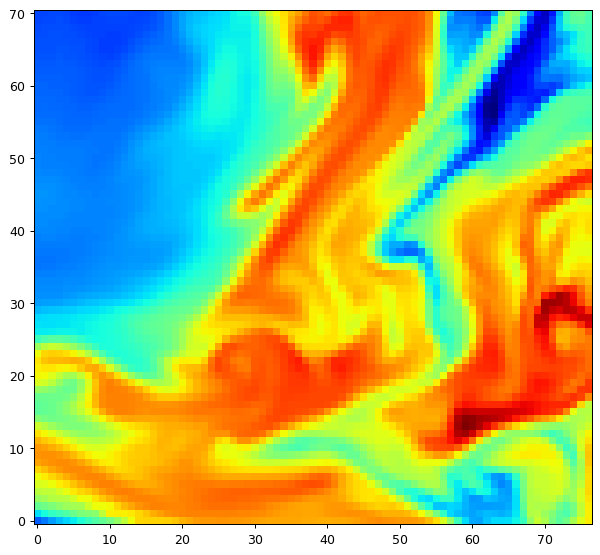

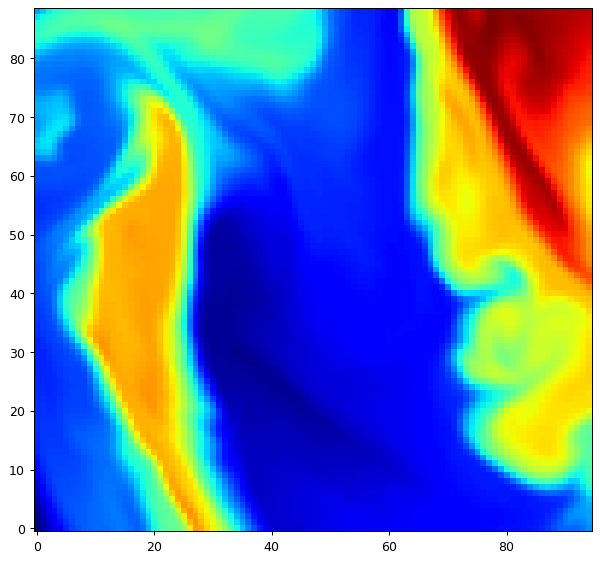

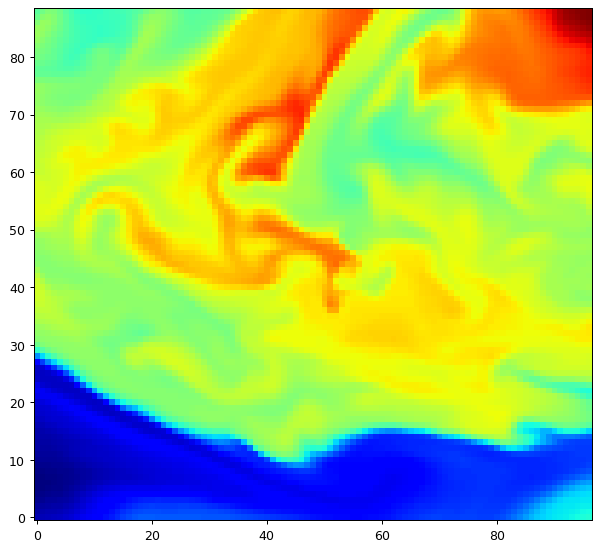

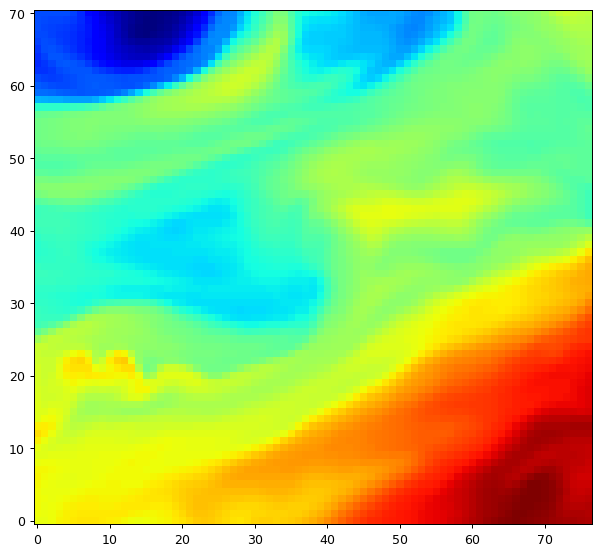

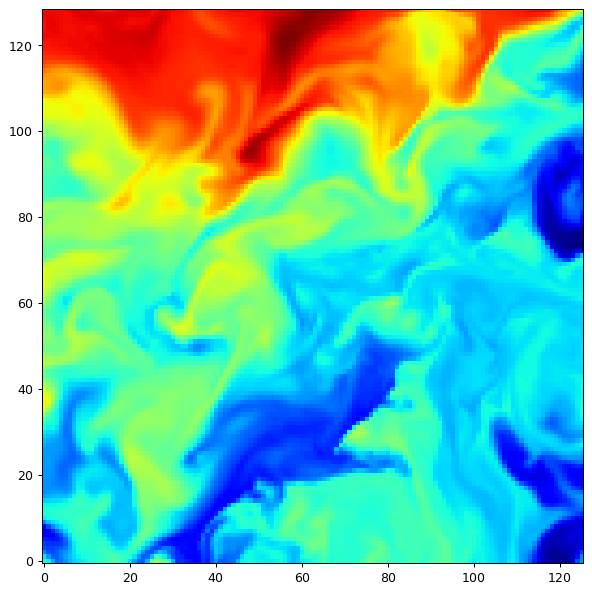

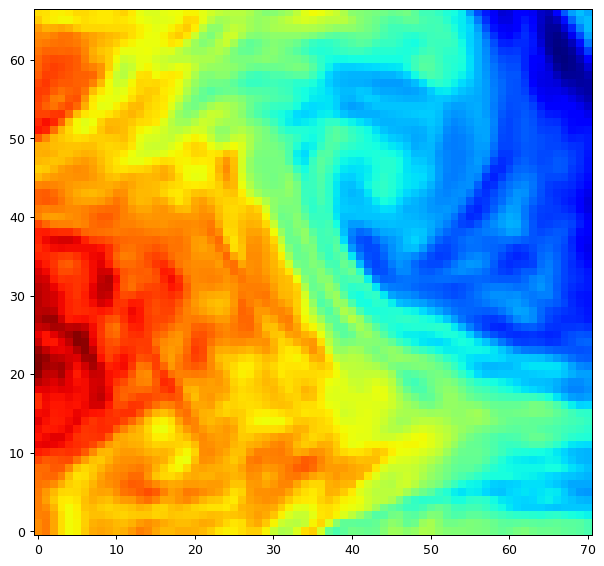

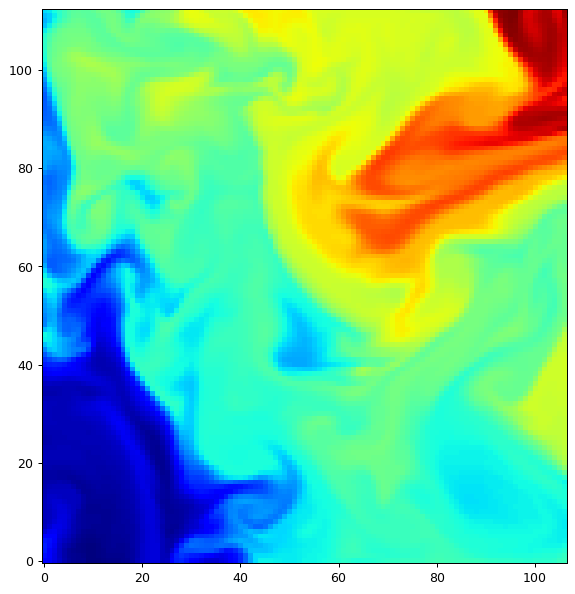

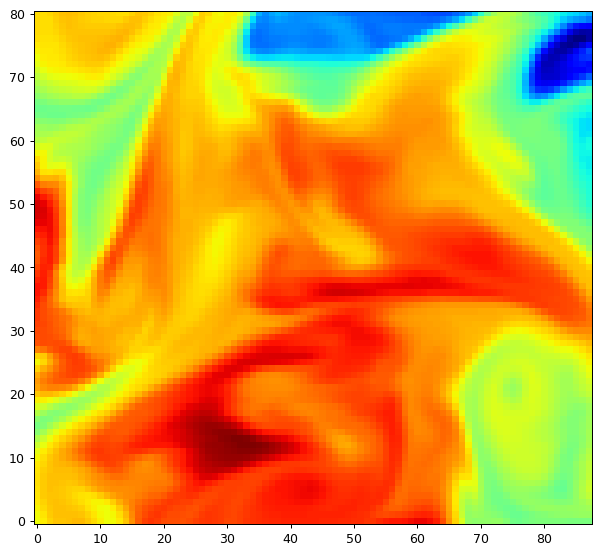

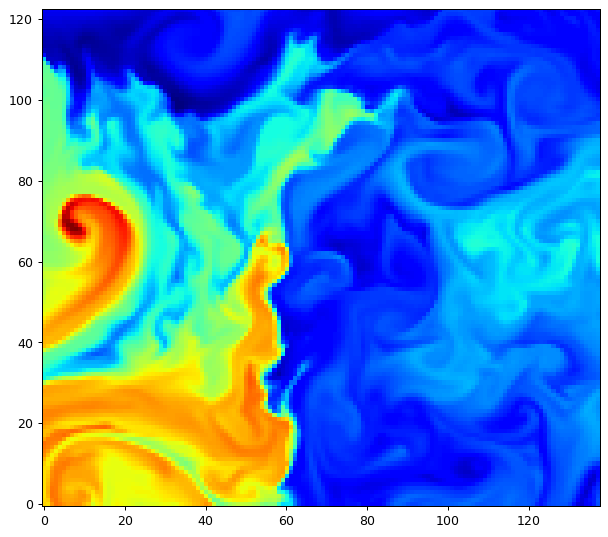

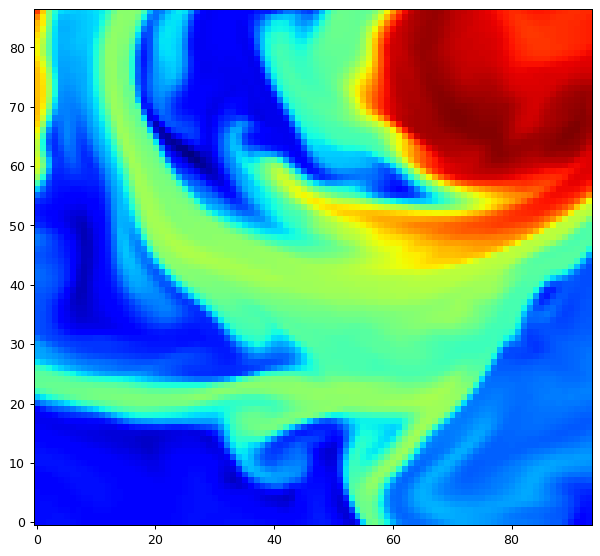

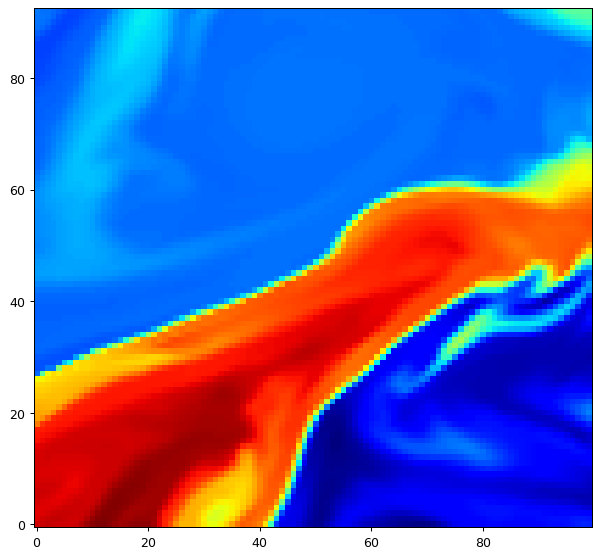

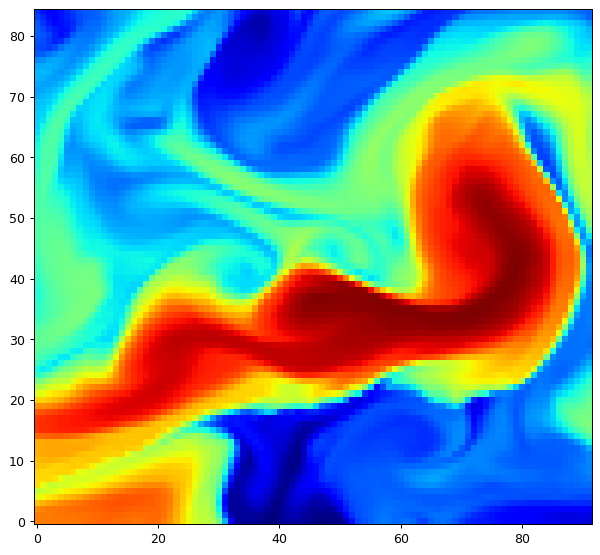

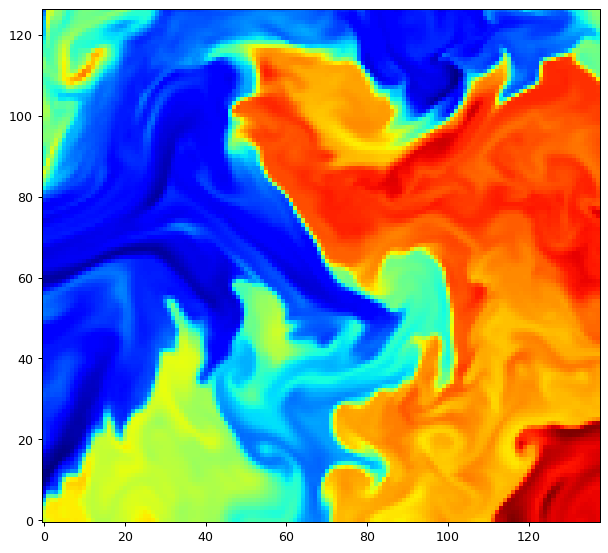

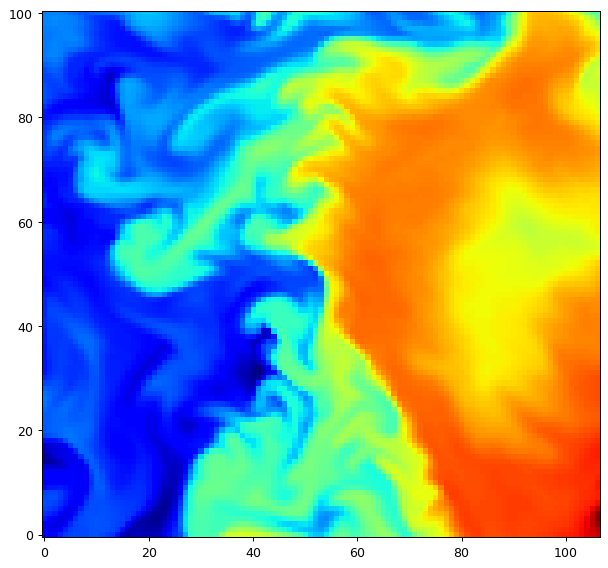

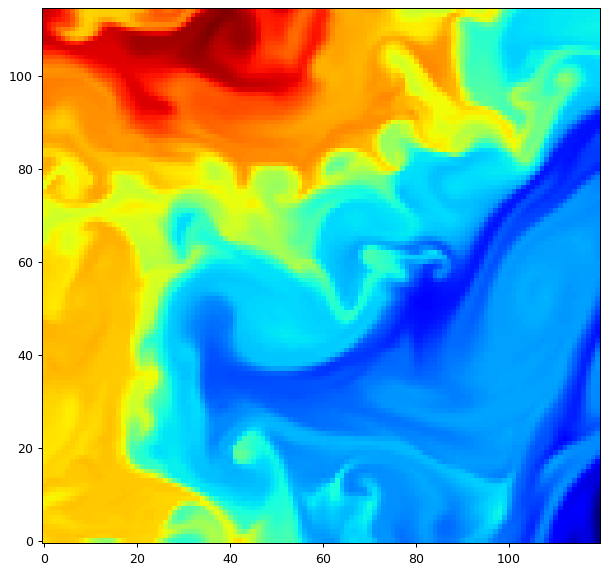

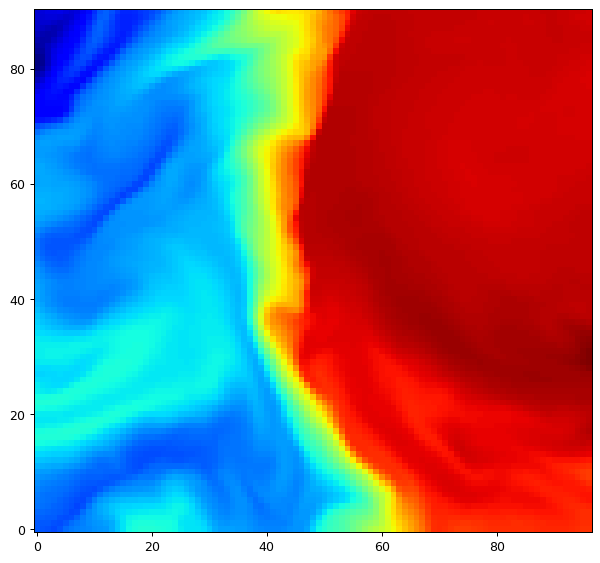

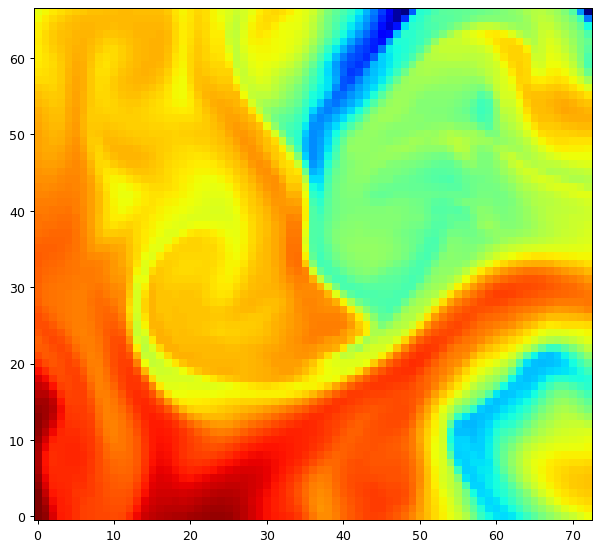

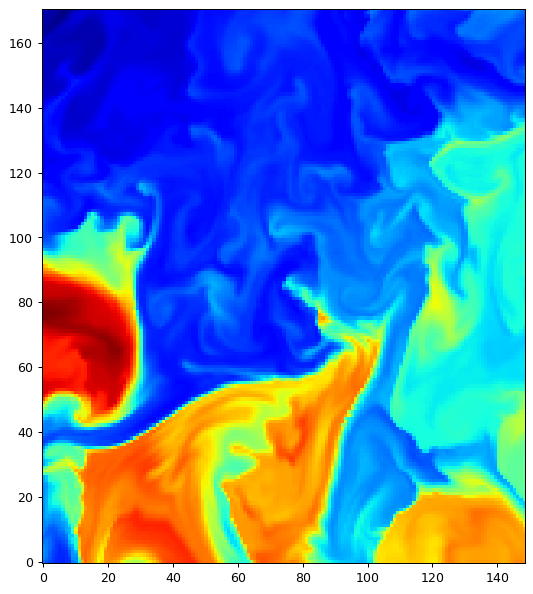

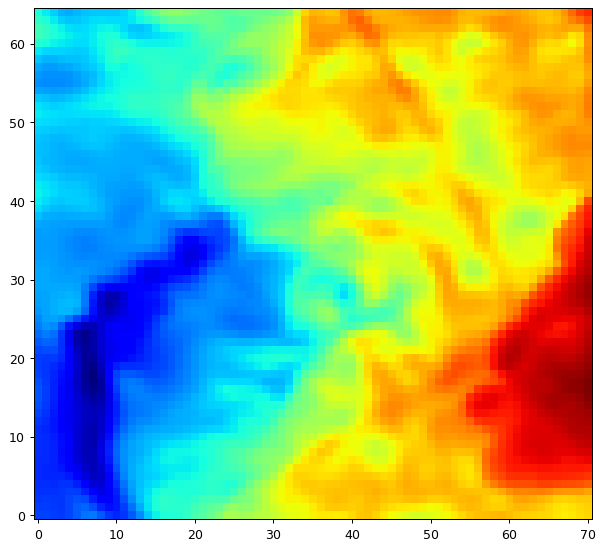

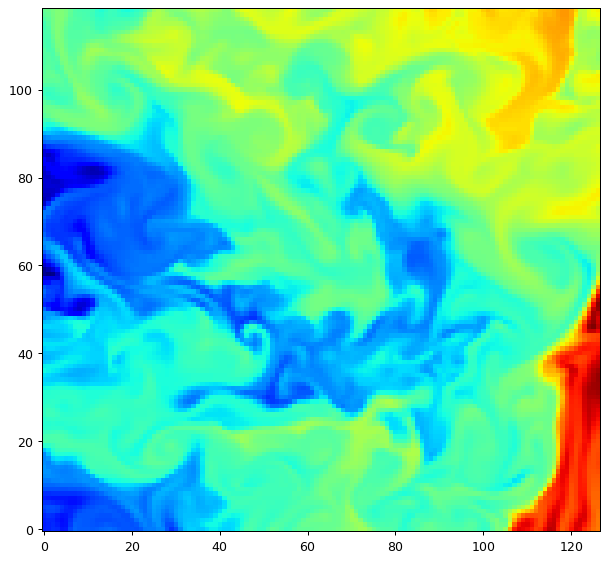

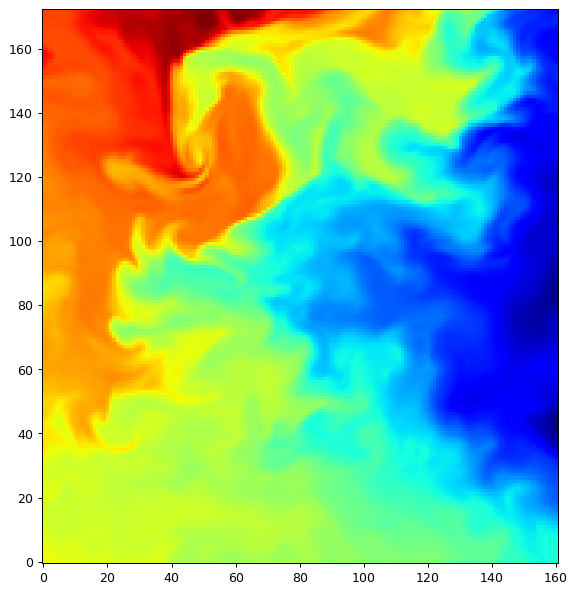

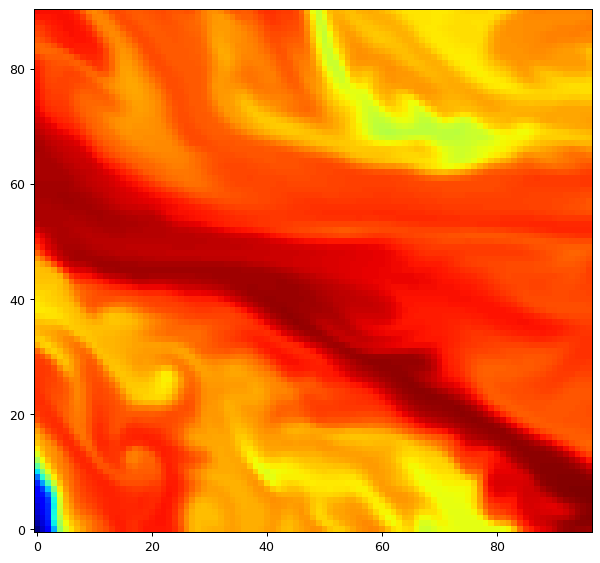

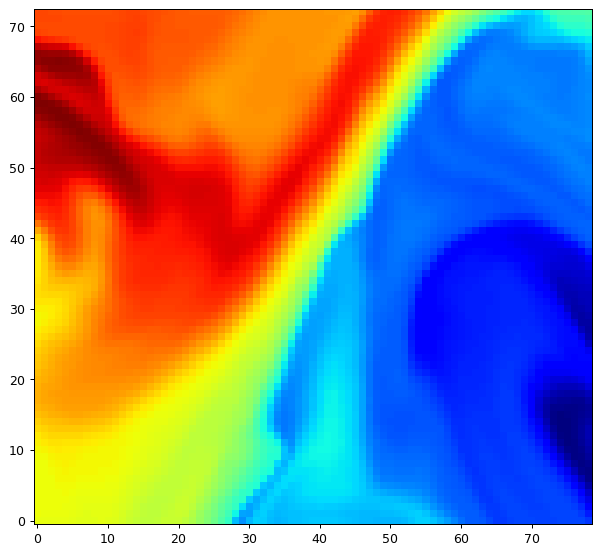

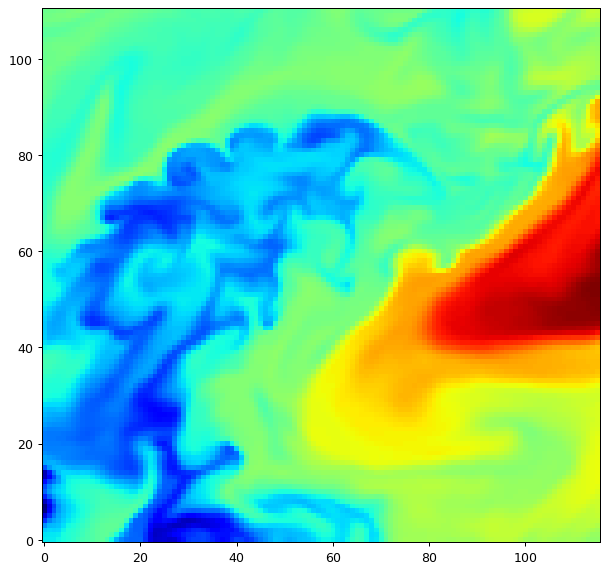

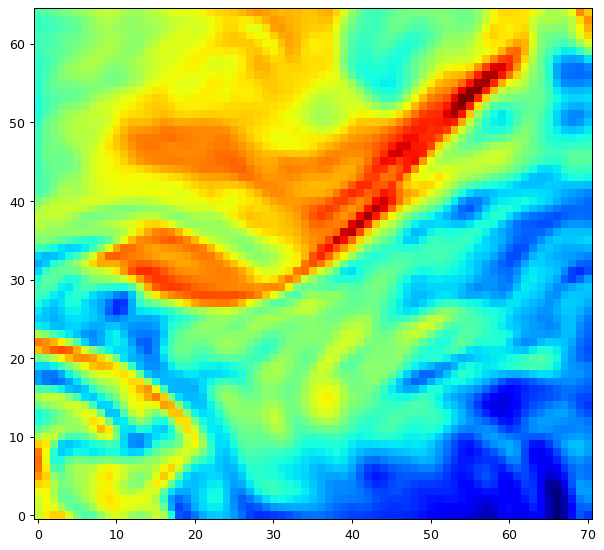

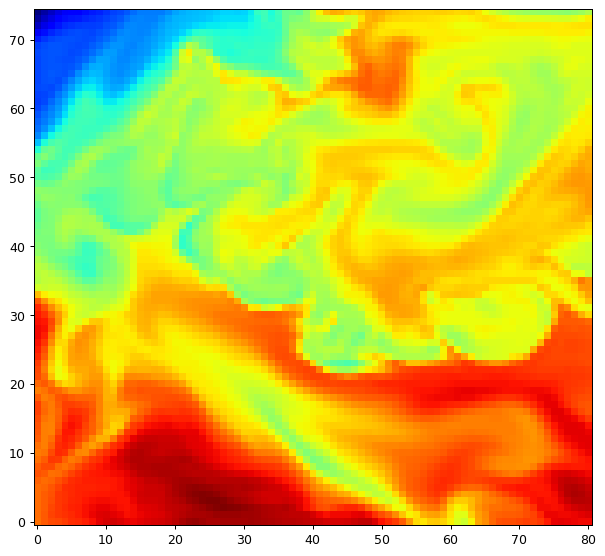

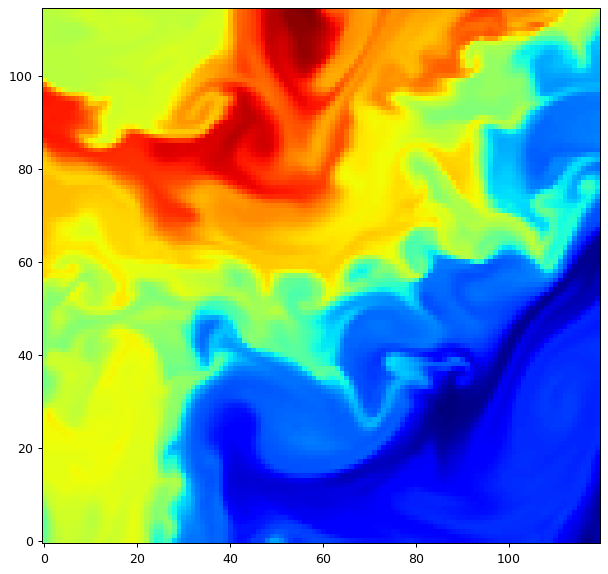

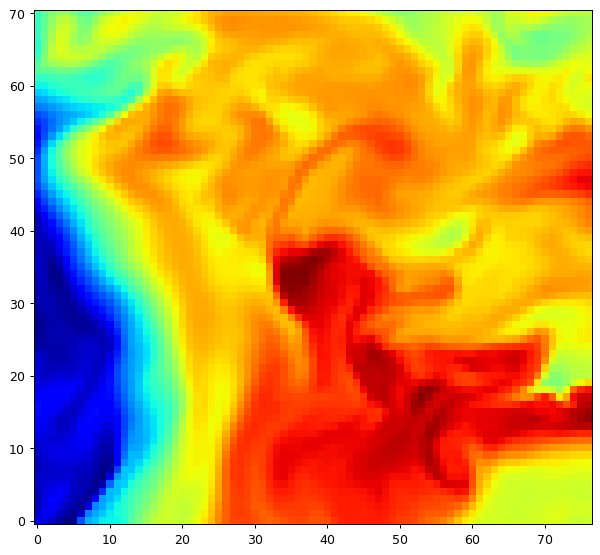

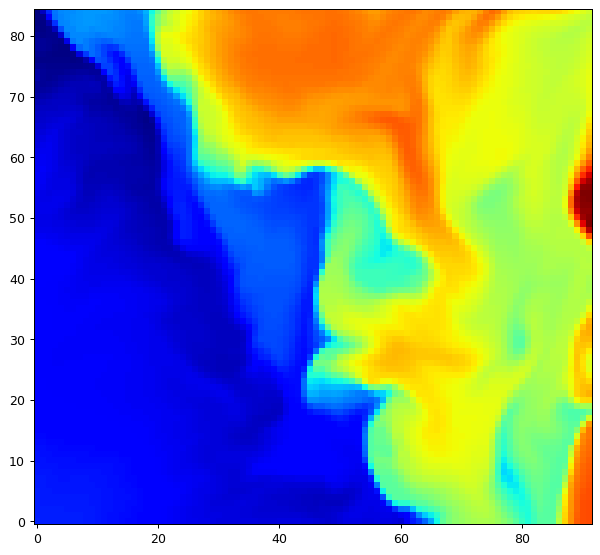

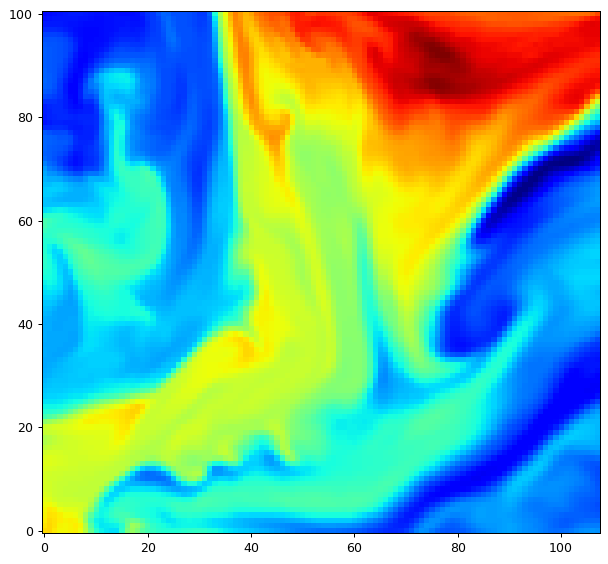

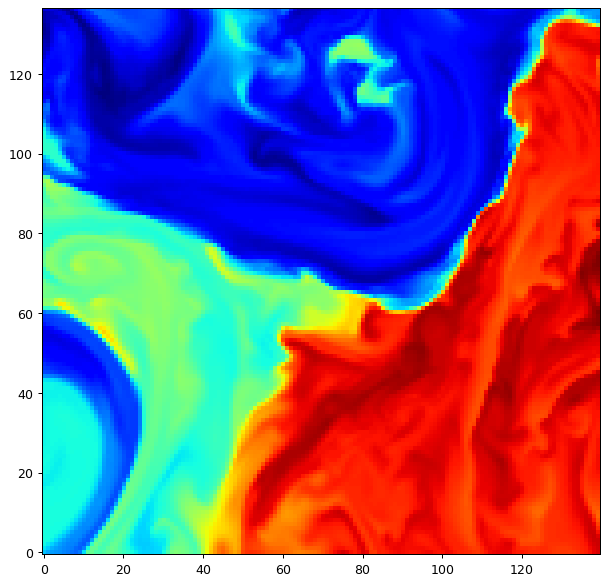

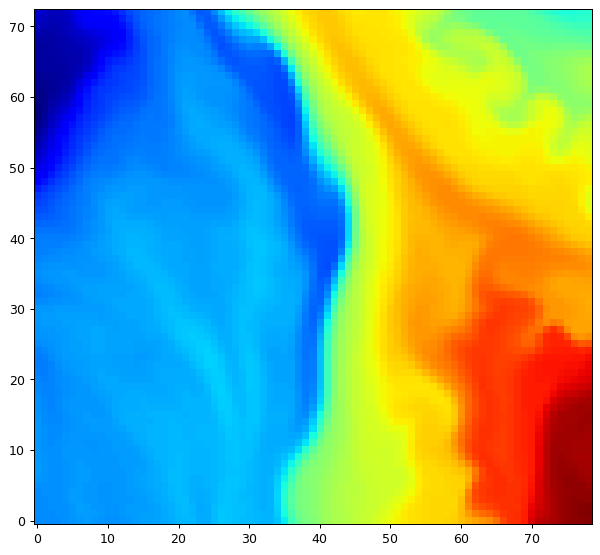

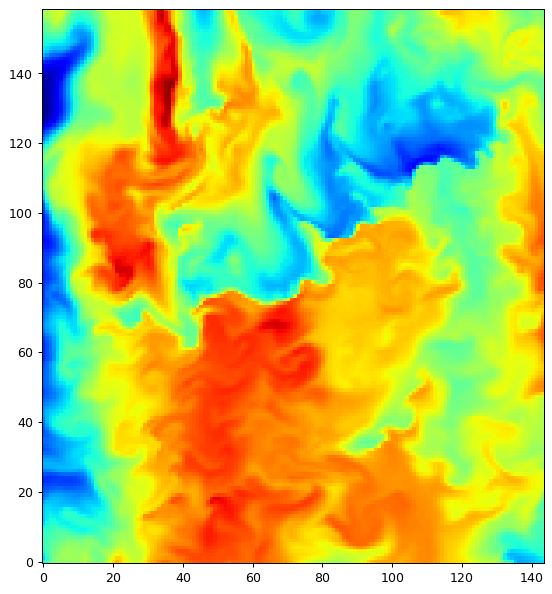

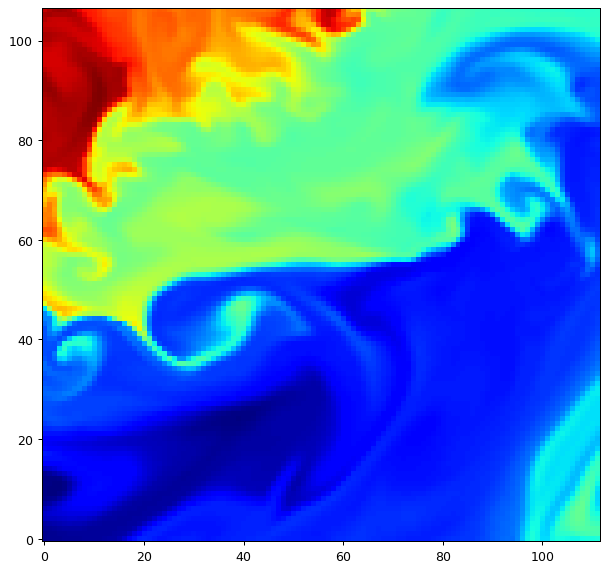

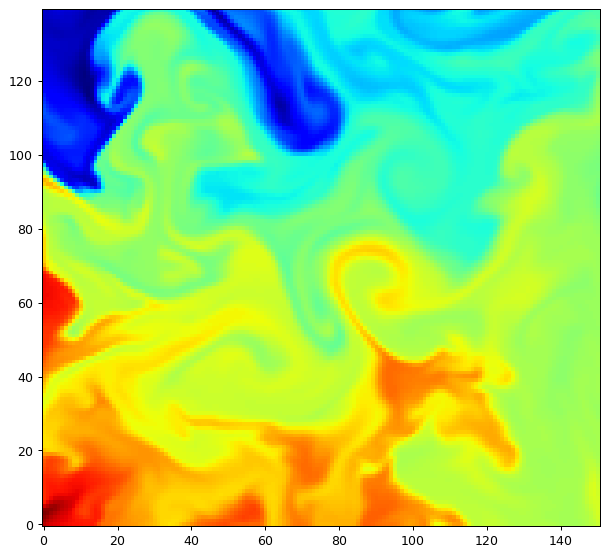

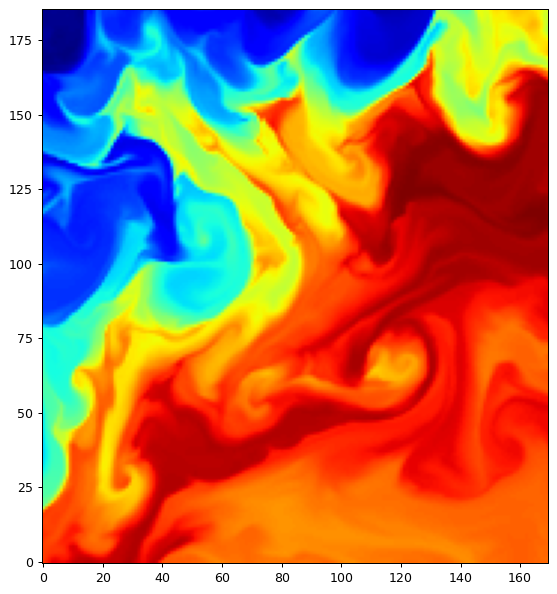

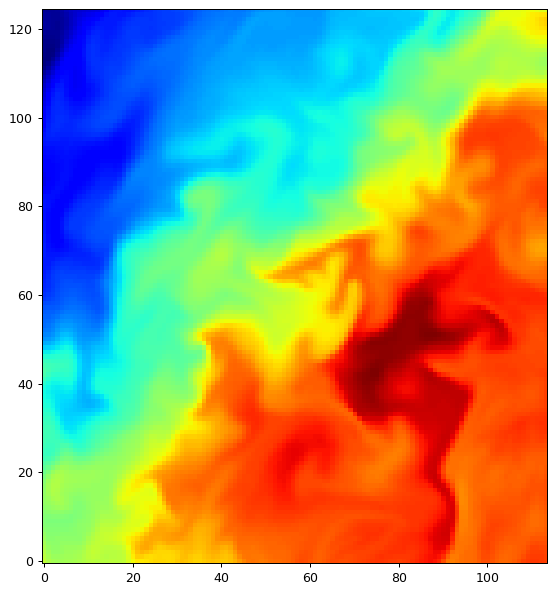

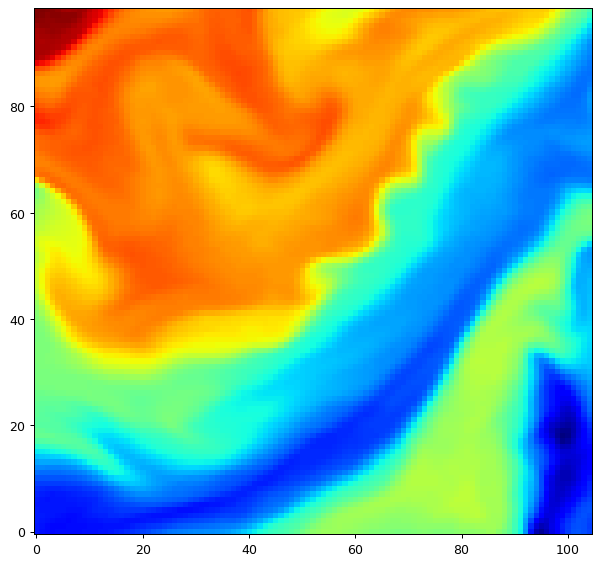

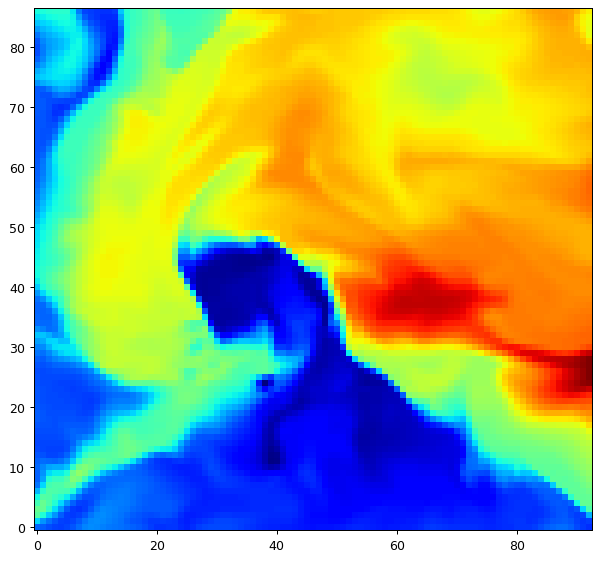

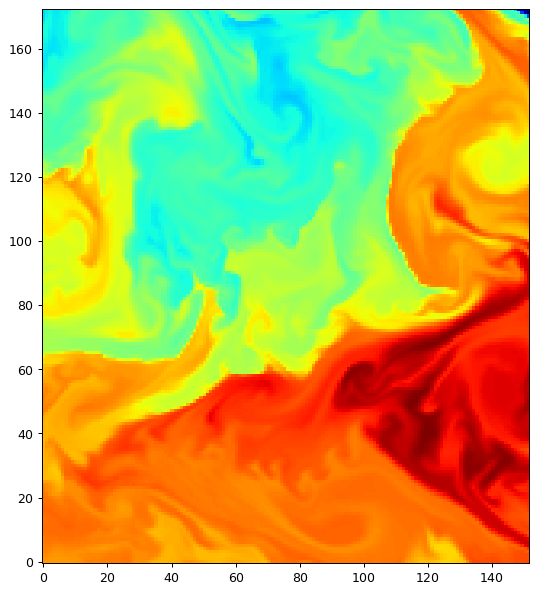

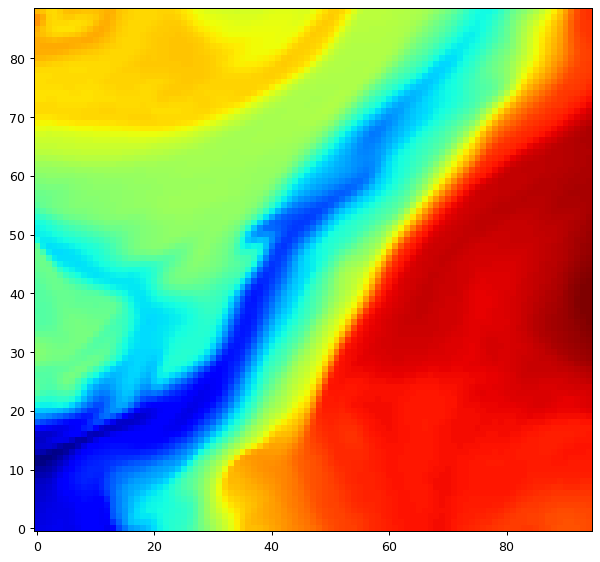

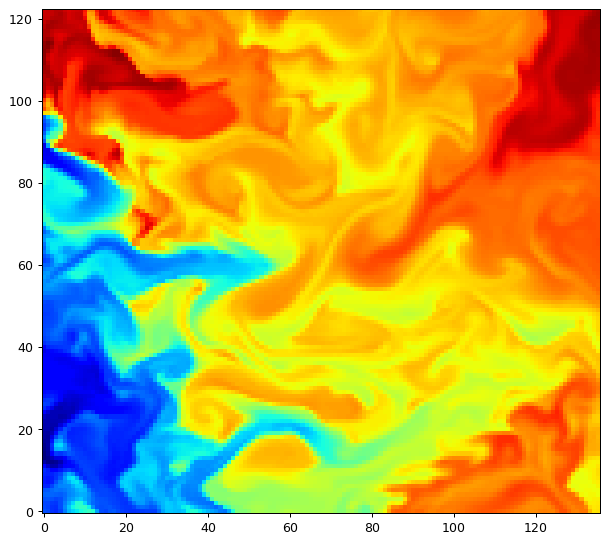

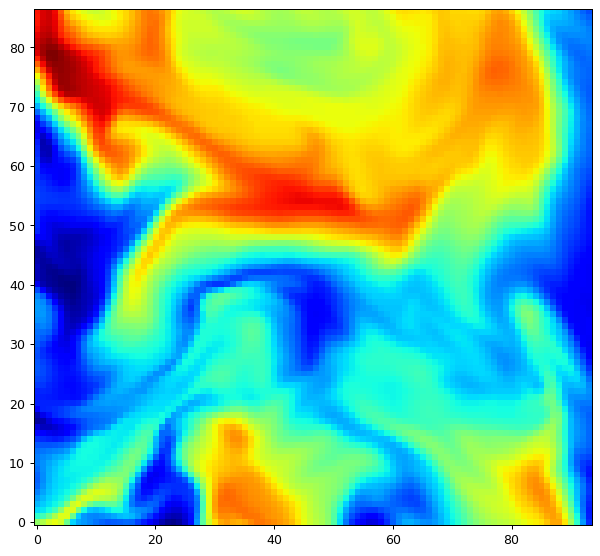

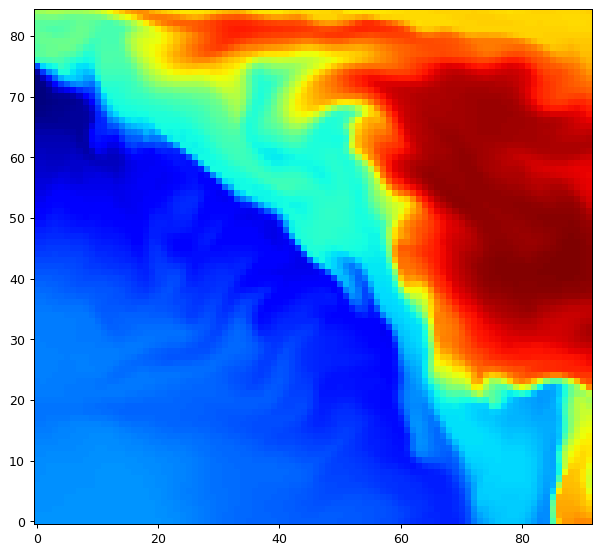

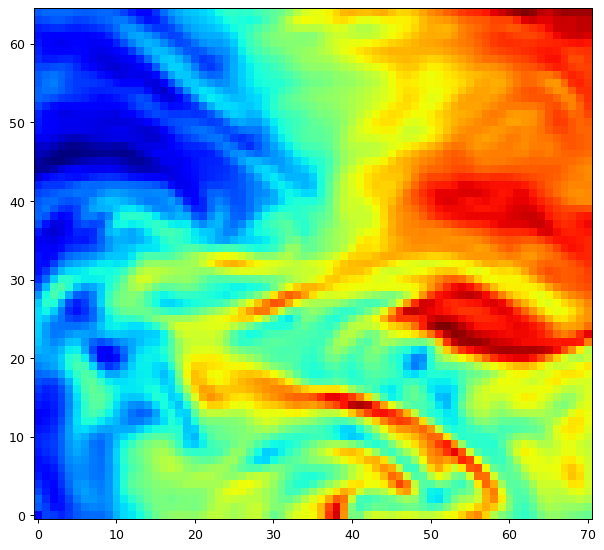

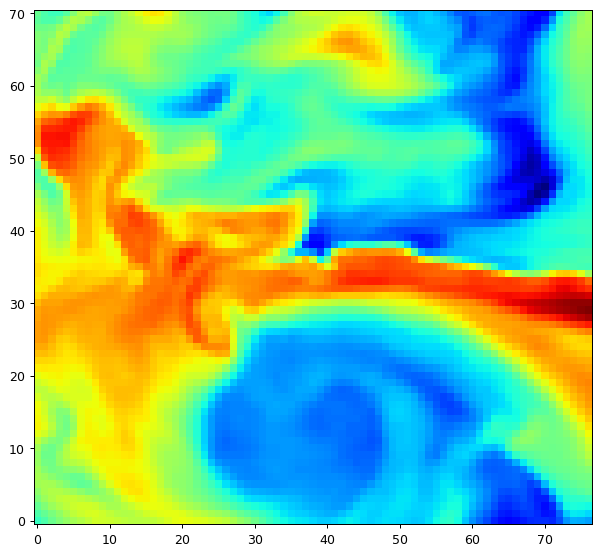

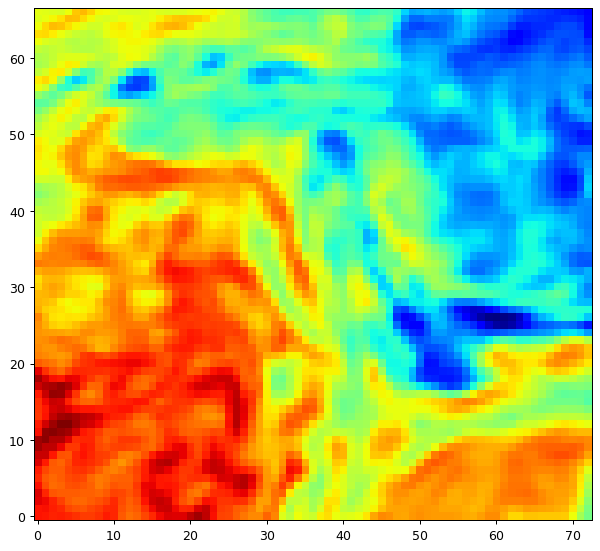

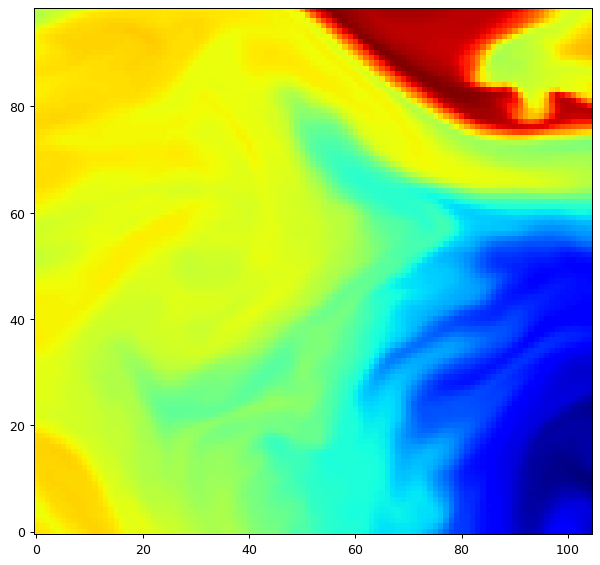

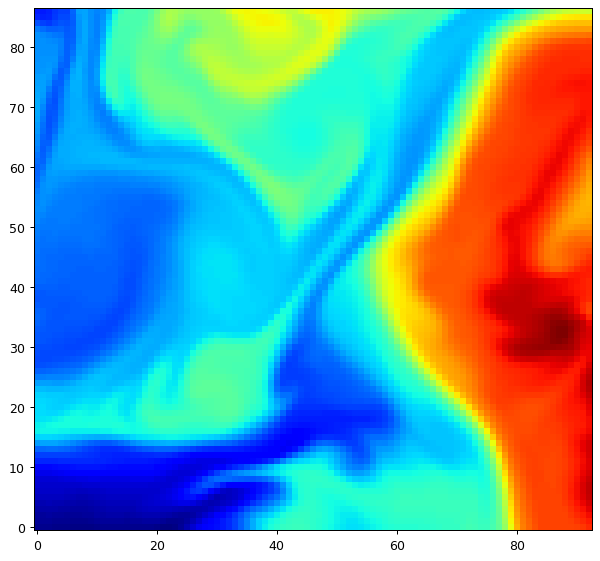

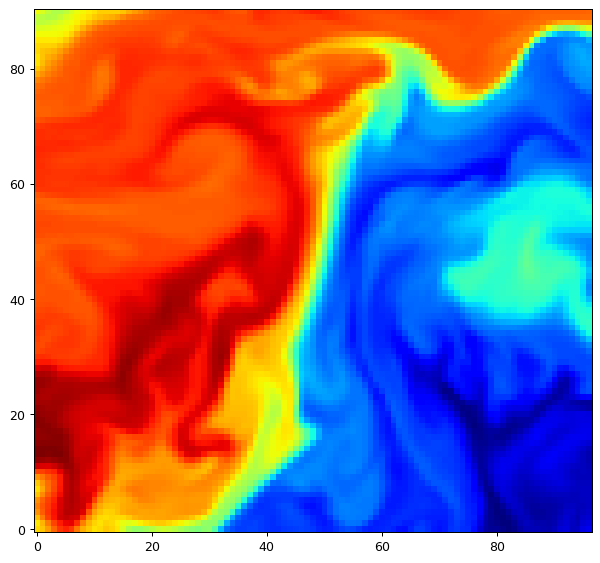

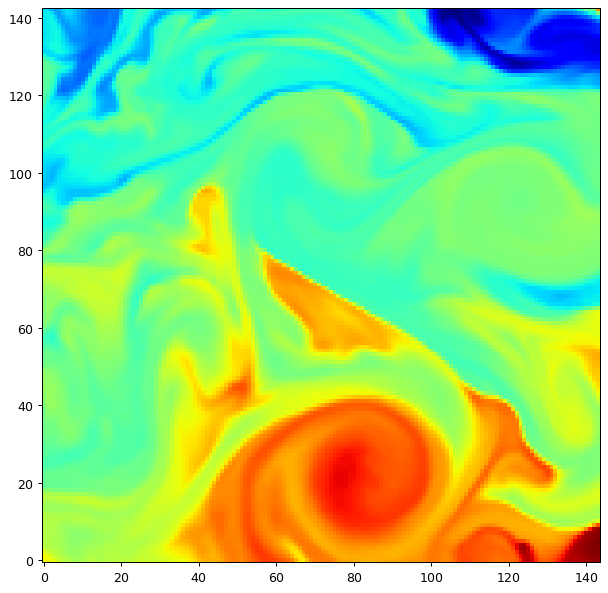

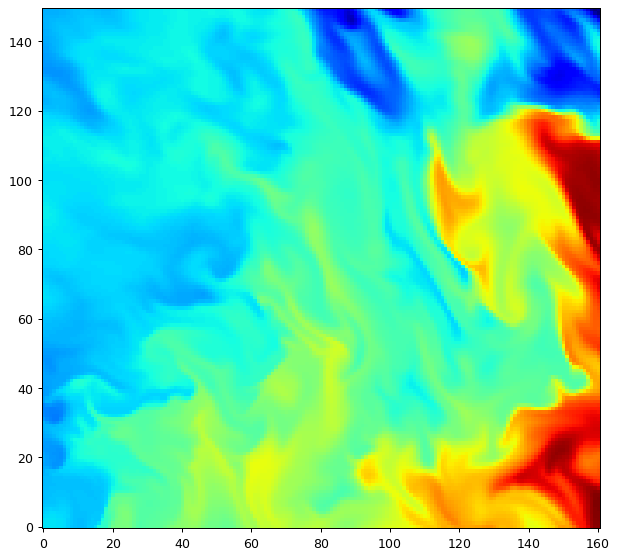

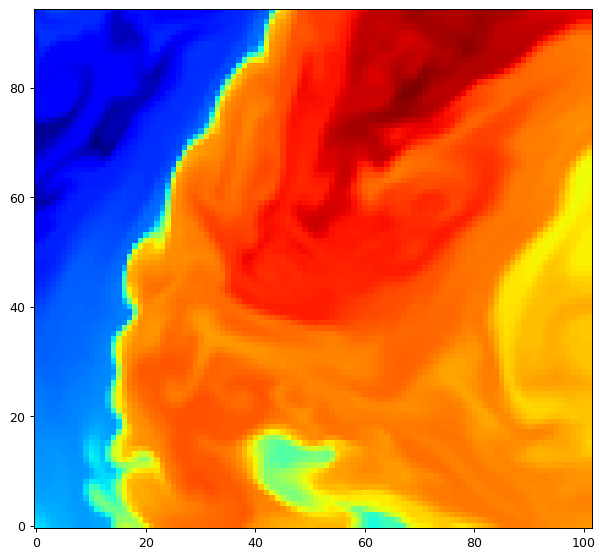

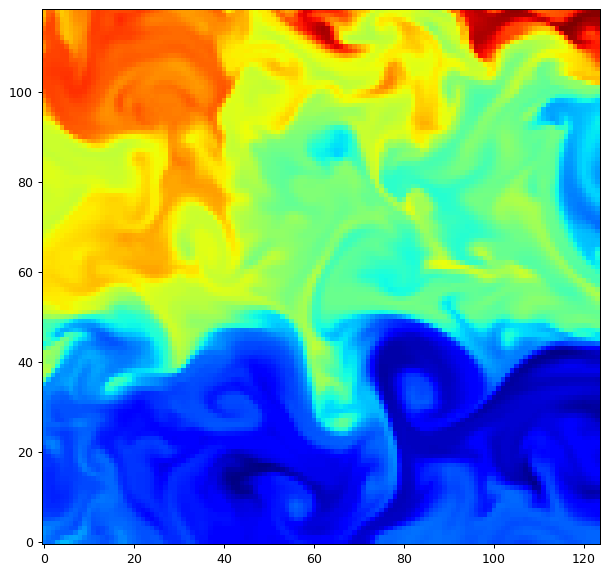

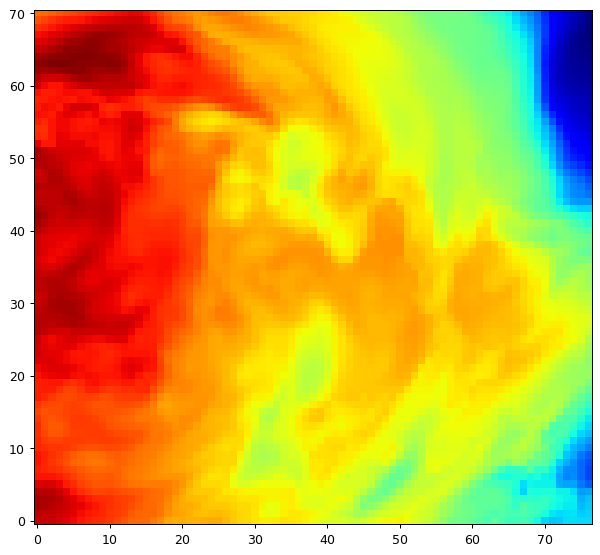

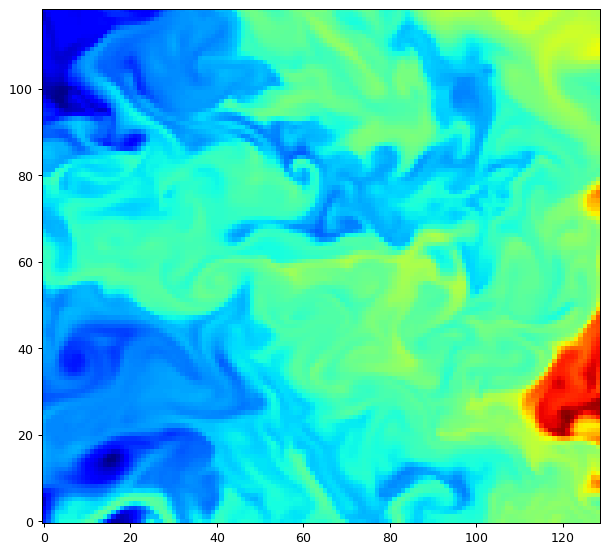

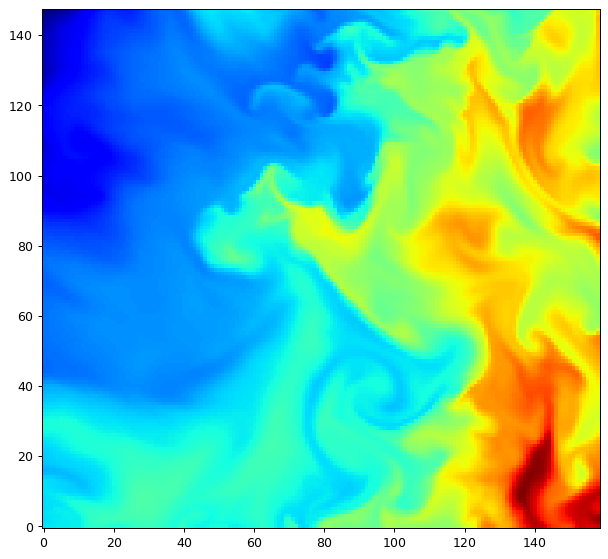

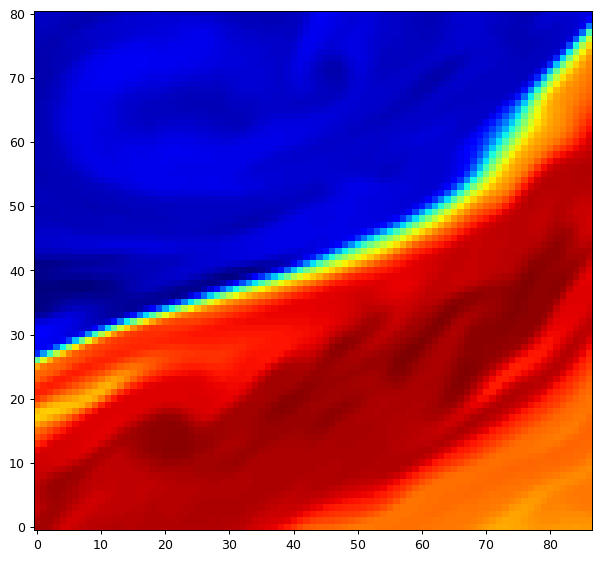

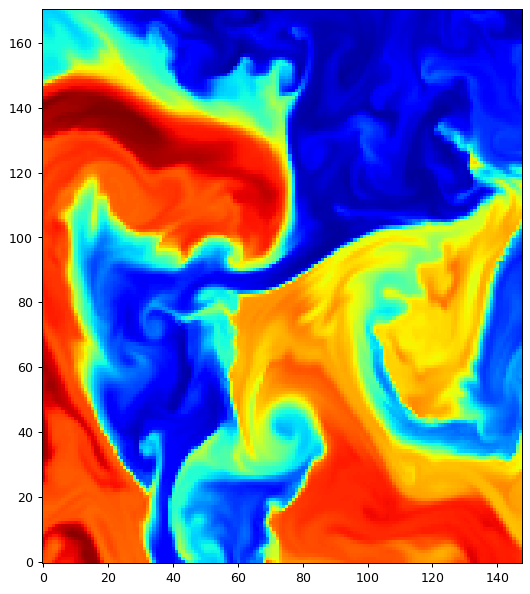

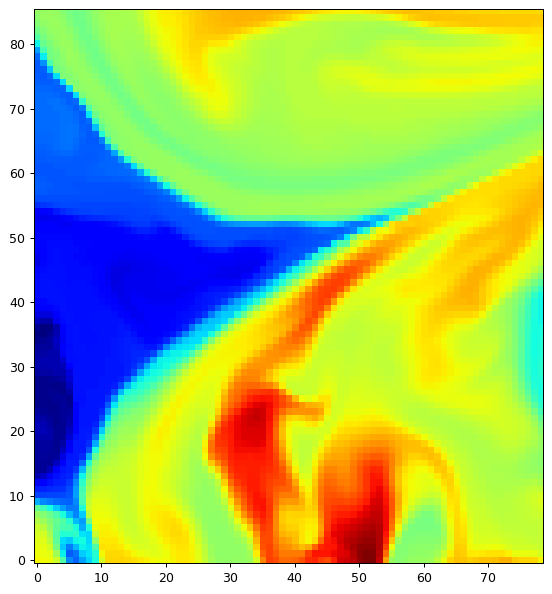

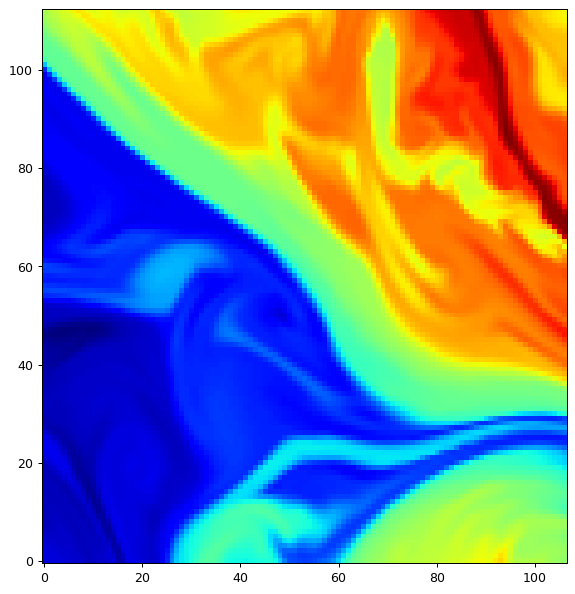

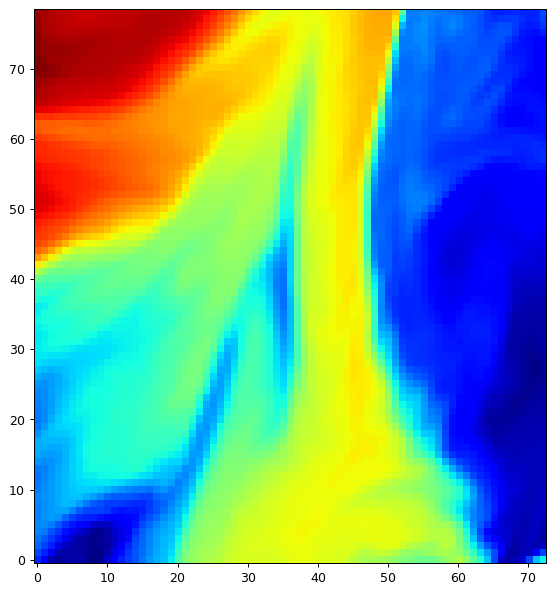

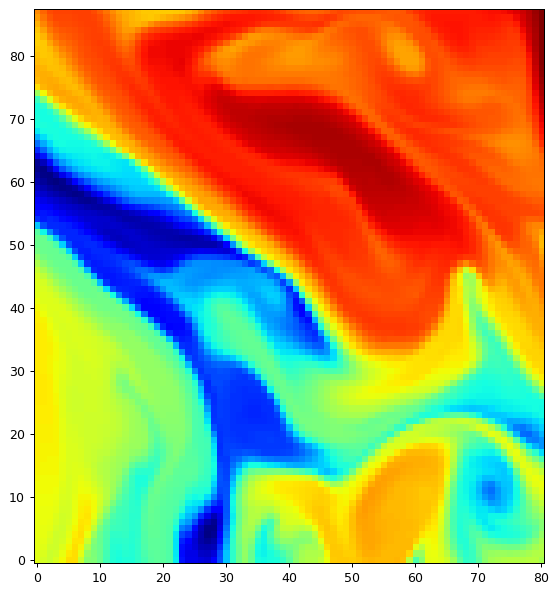

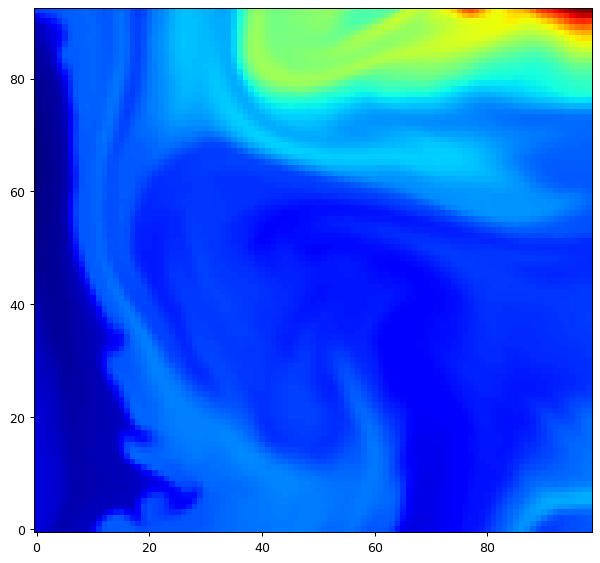

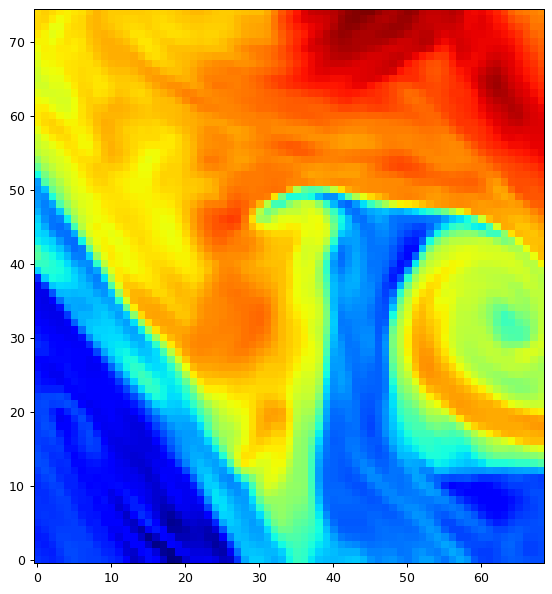

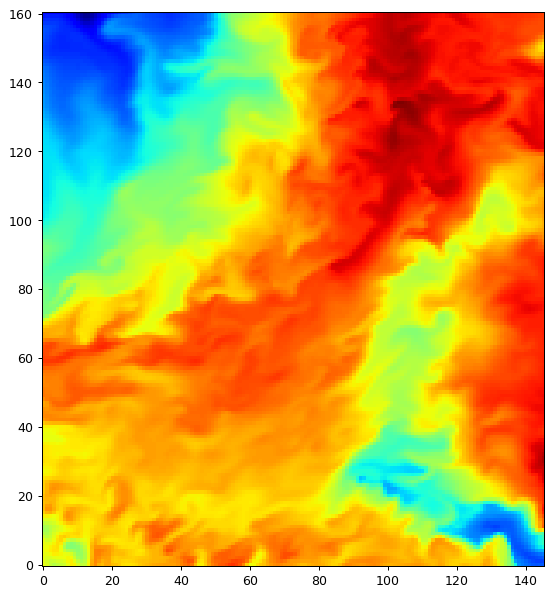

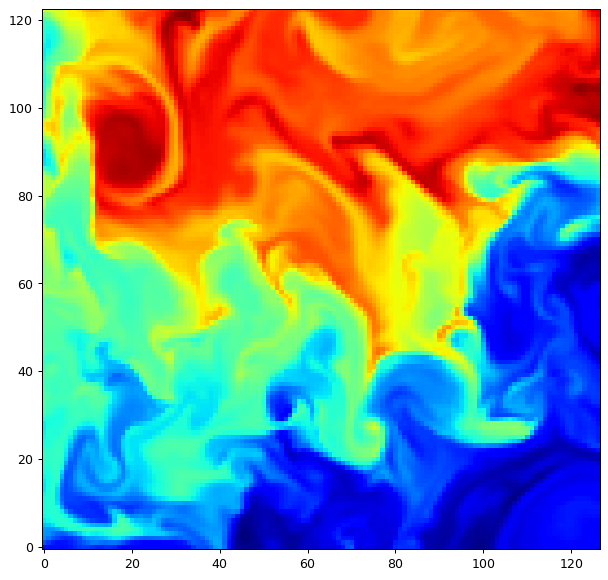

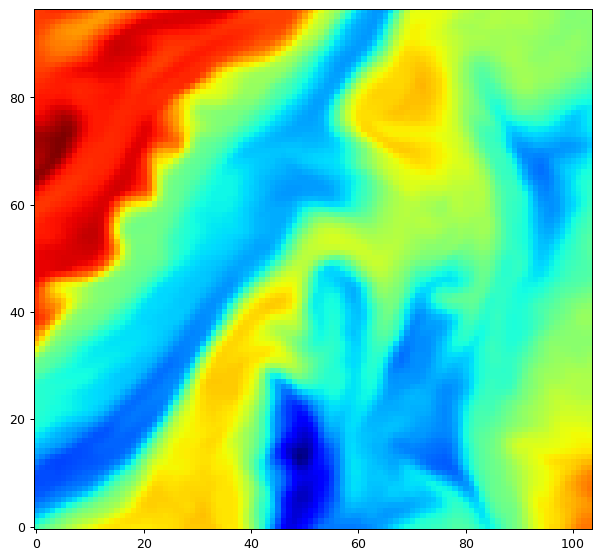

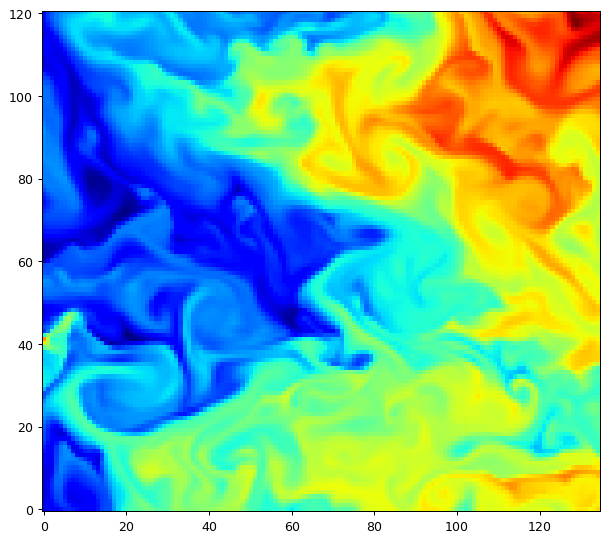

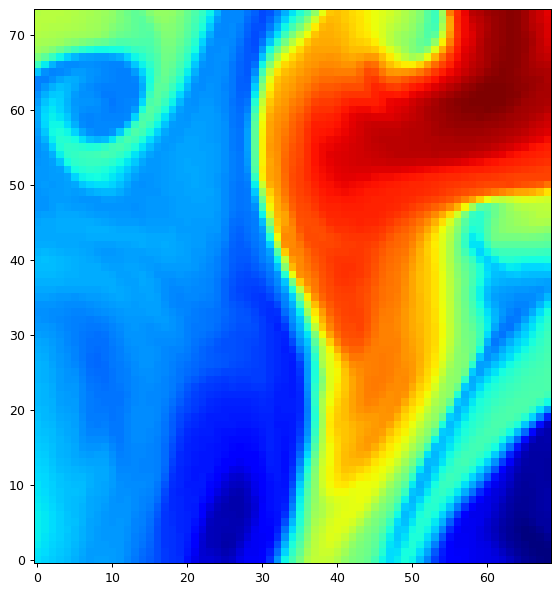

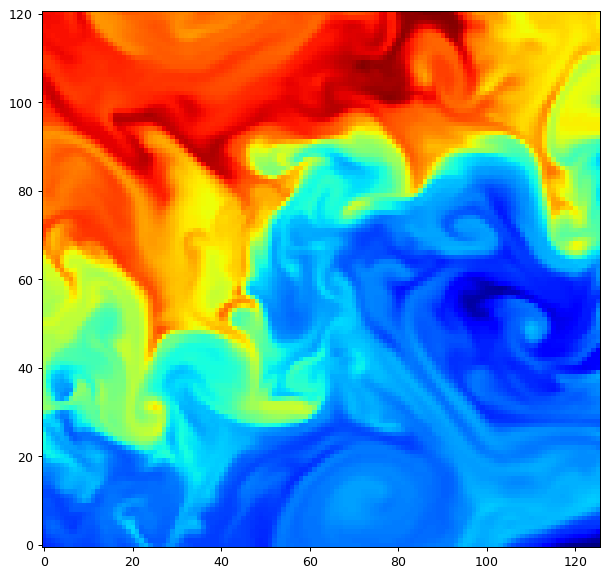

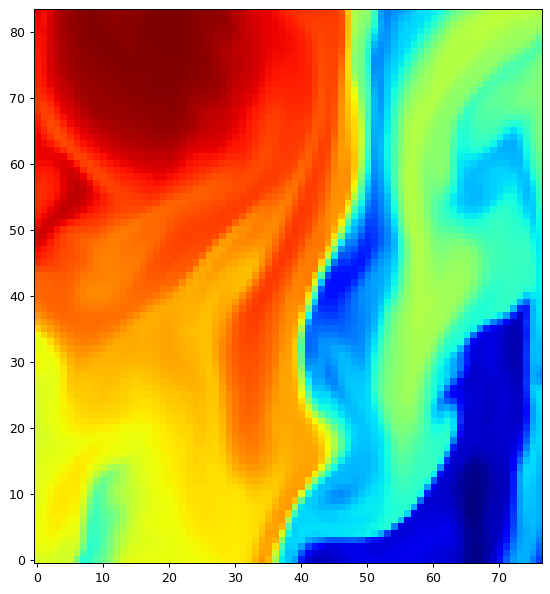

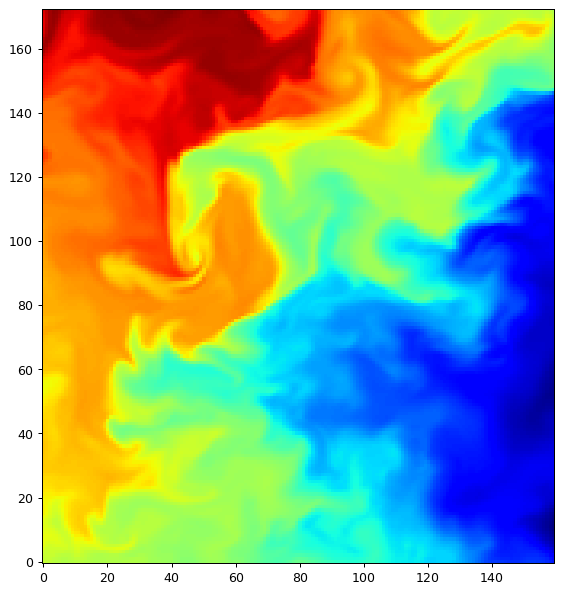

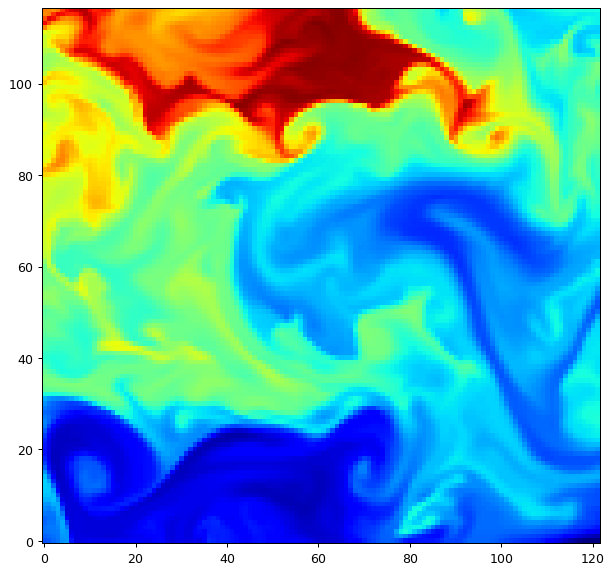

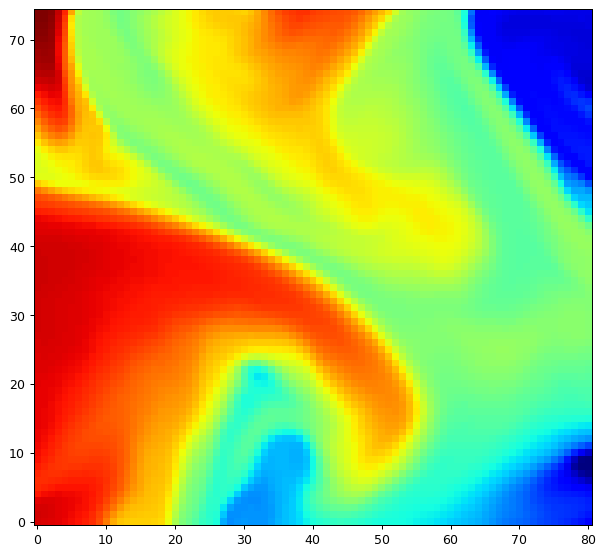

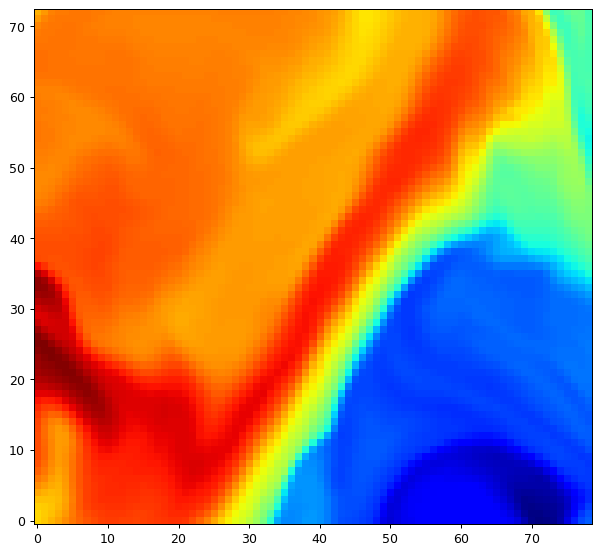

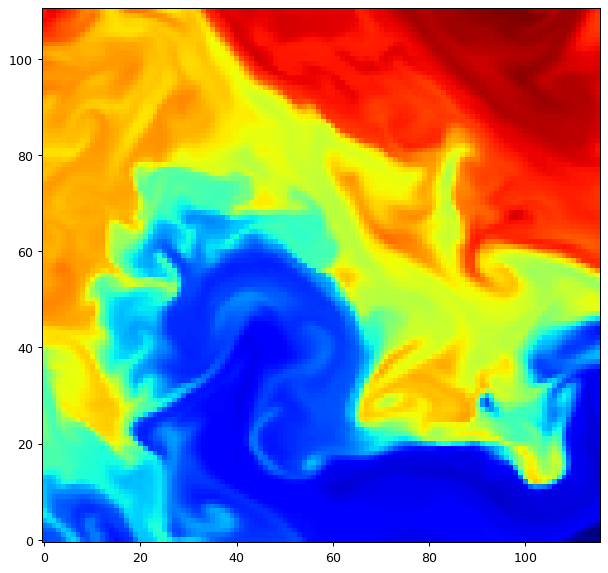

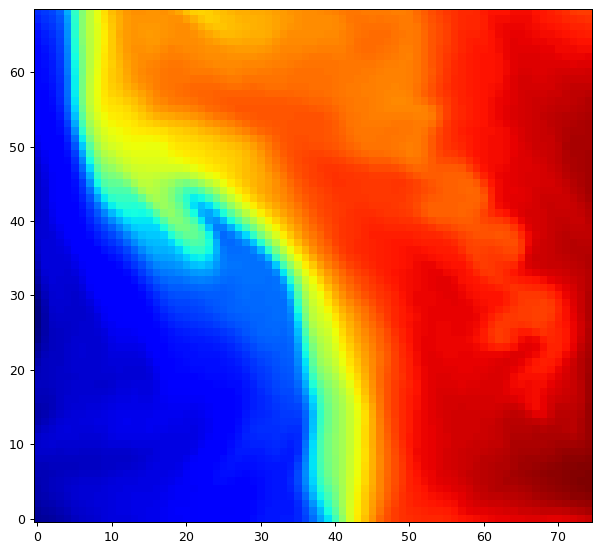

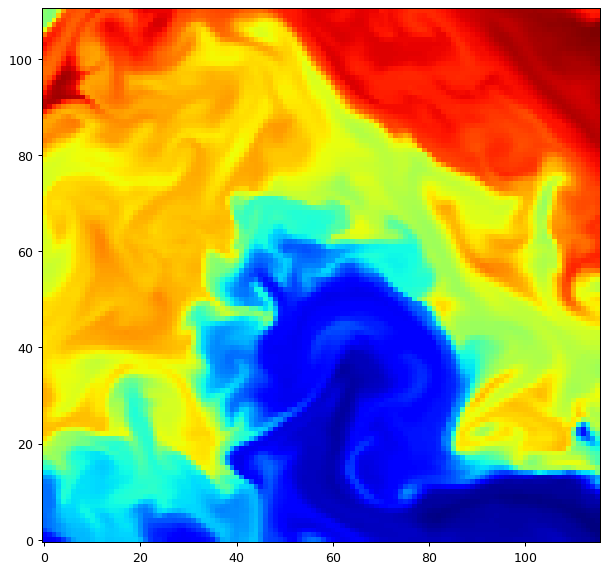

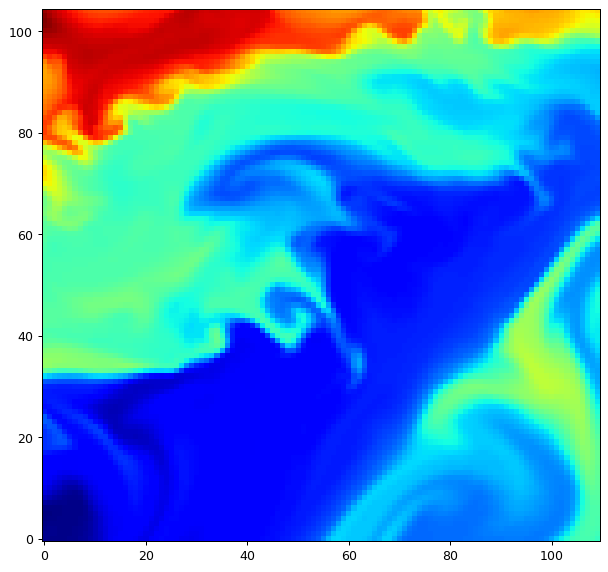

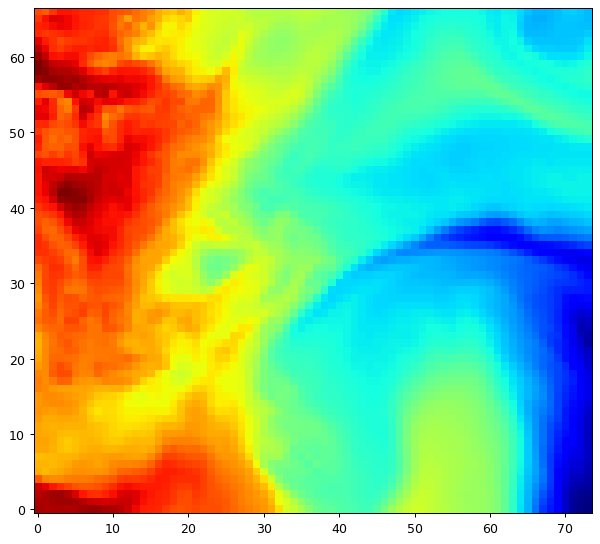

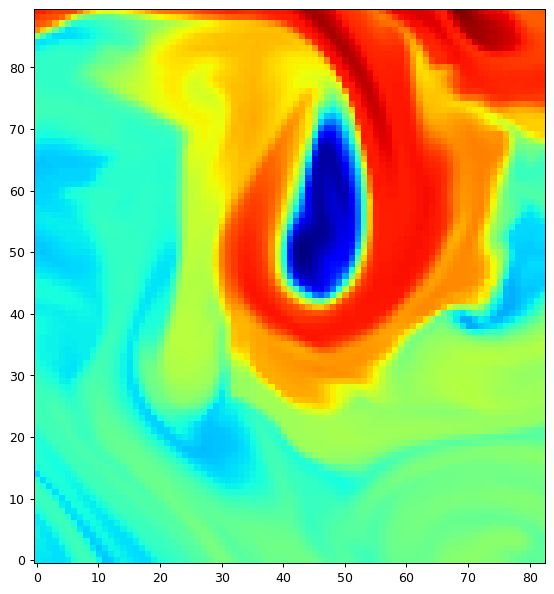

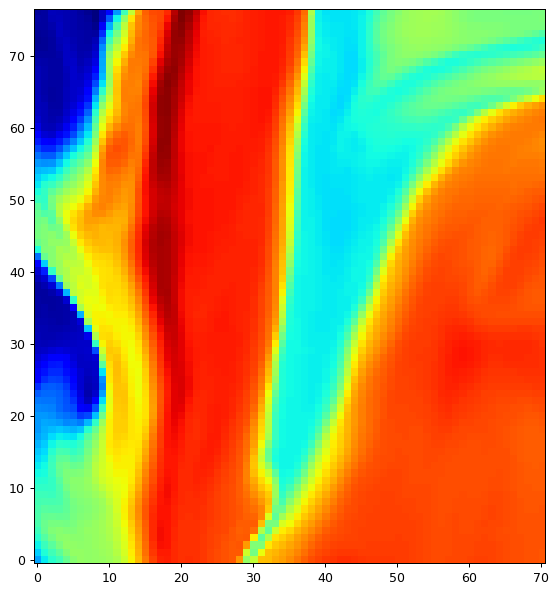

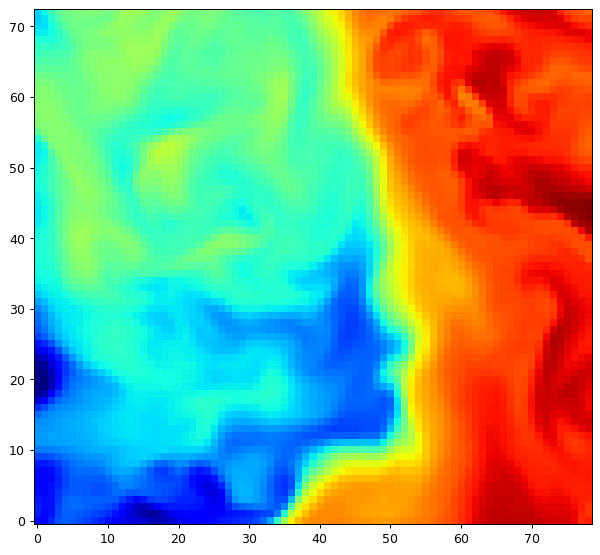

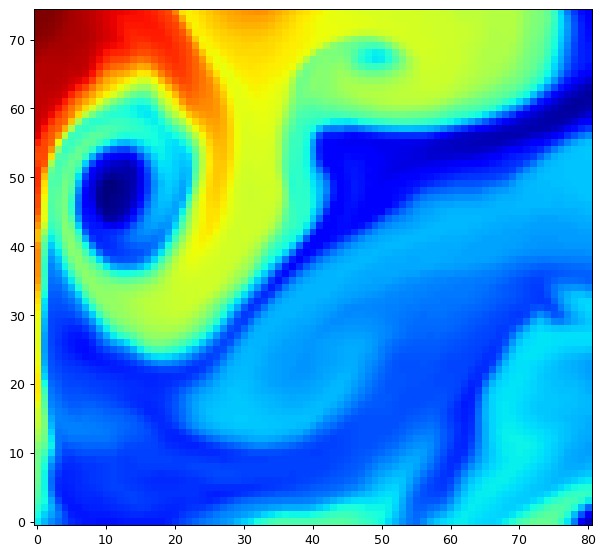

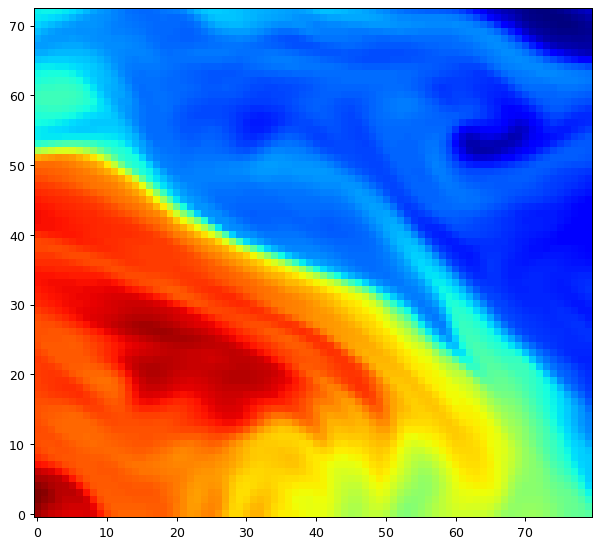

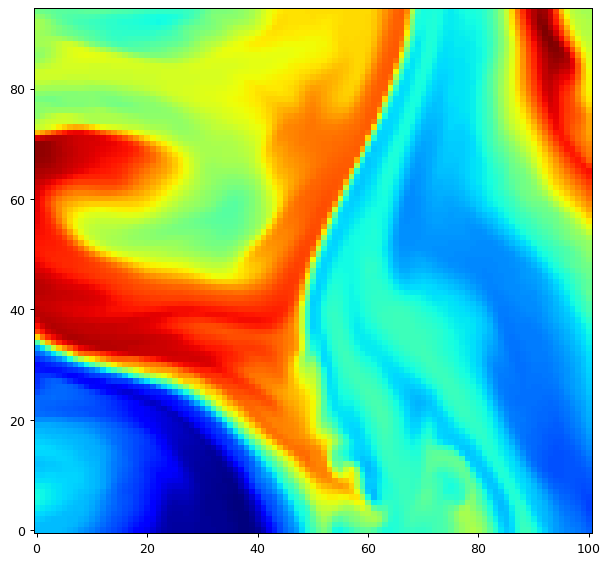

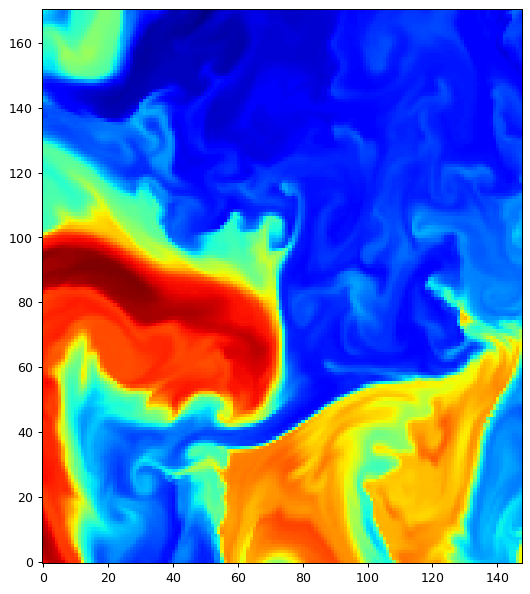

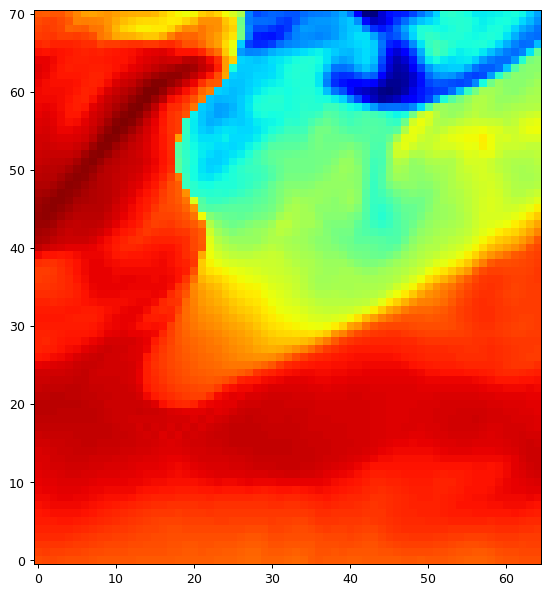

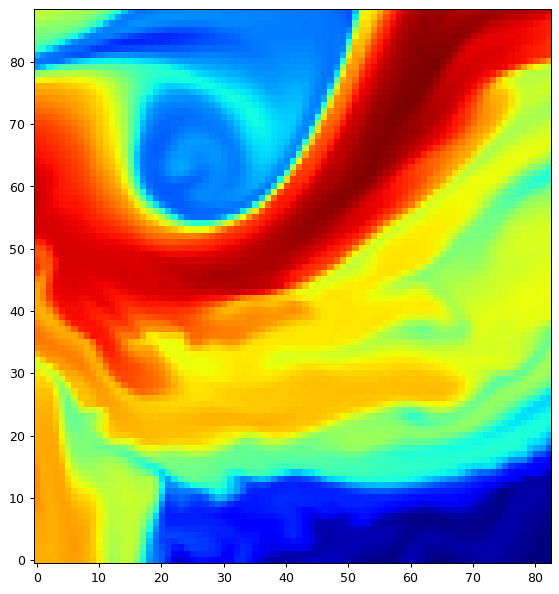

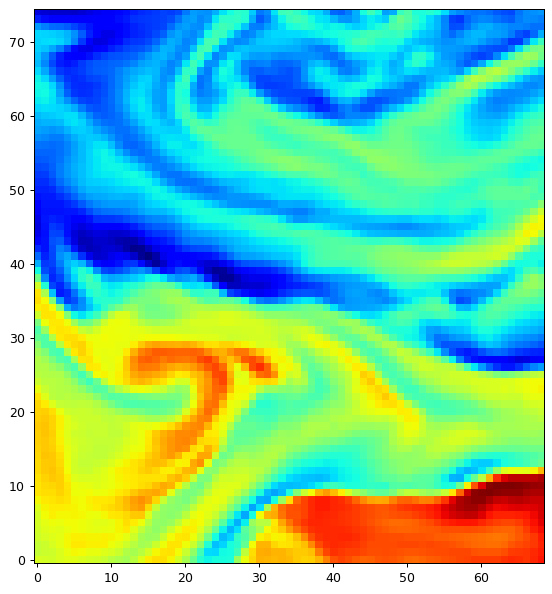

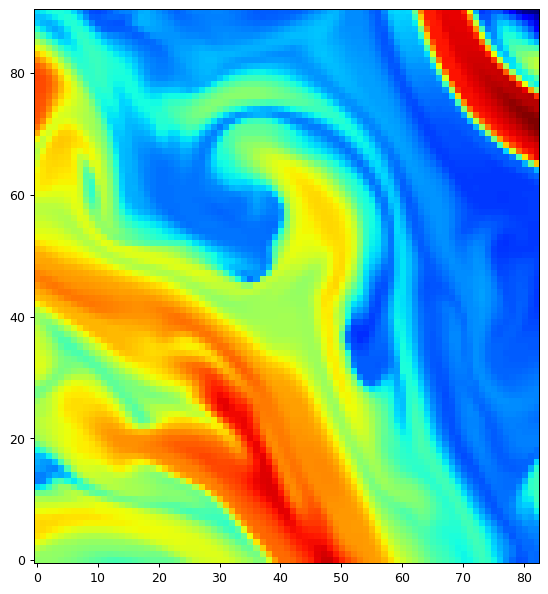

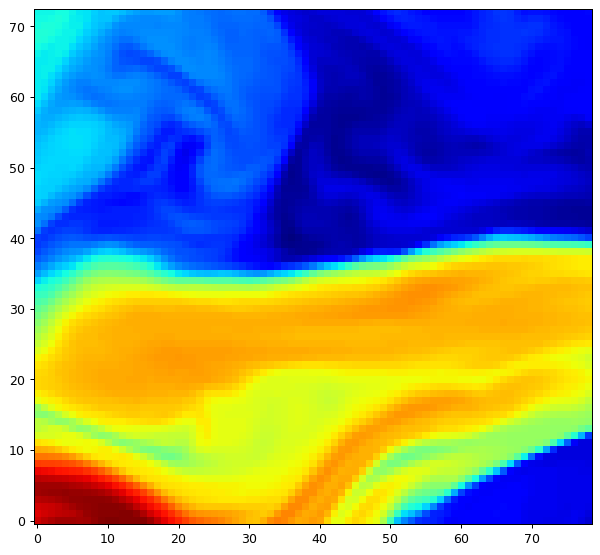

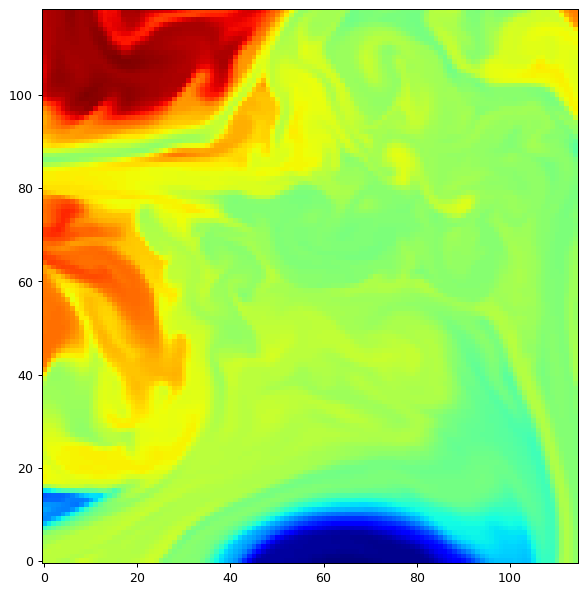

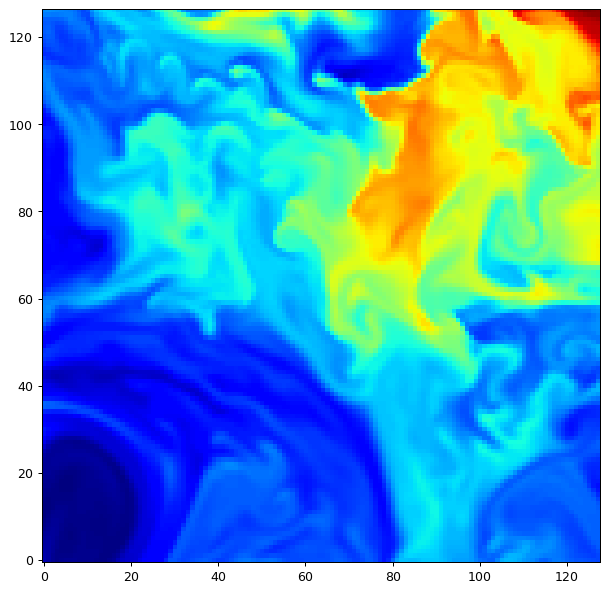

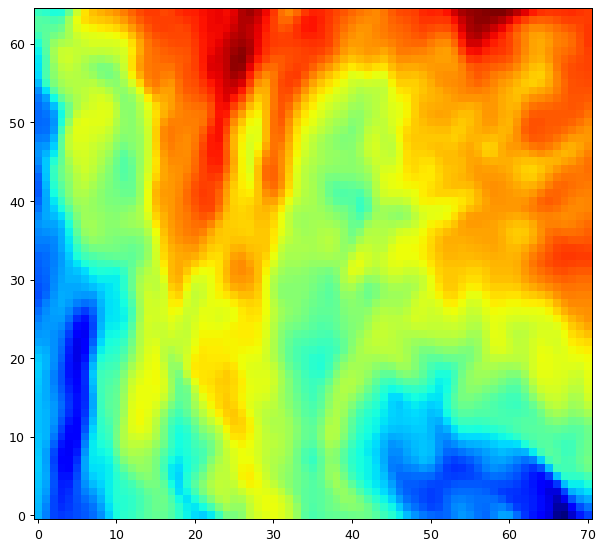

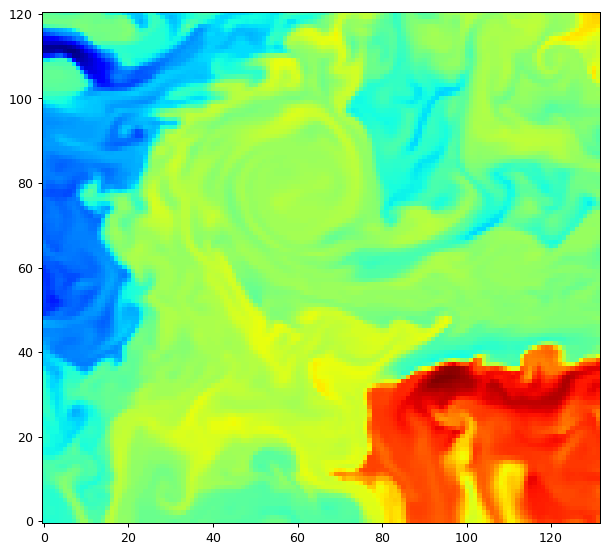

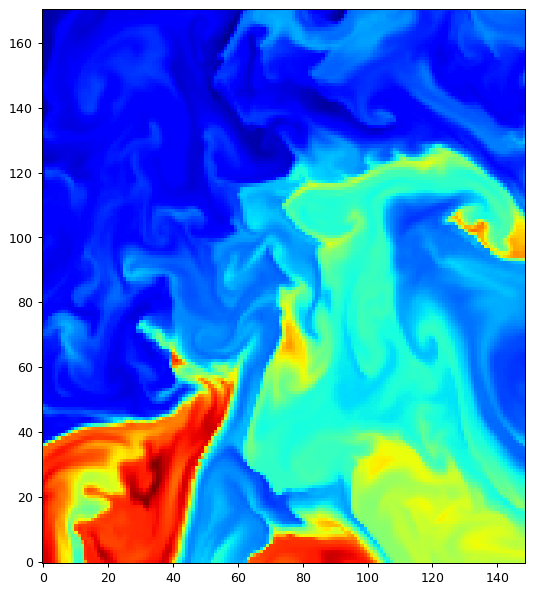

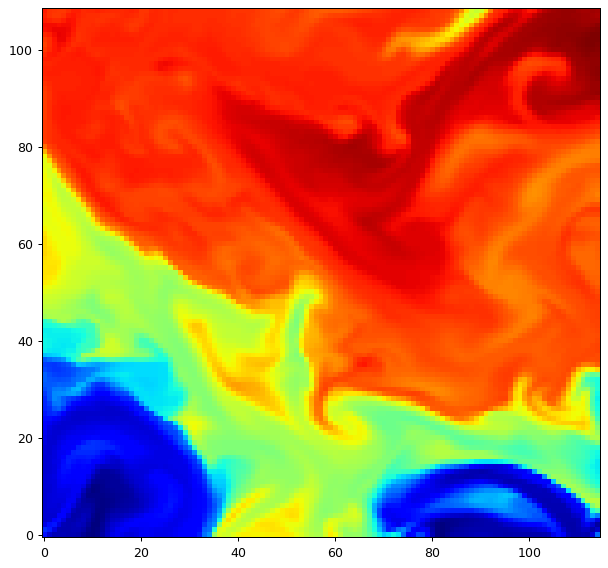

In [74]:

# print(latlon_dict["j_end"]-latlon_dict["j_start"])
# print(latlon_dict["i_end"]-latlon_dict["i_start"])
#
# print(latlon_dict["i_start"], latlon_dict["j_start"], latlon_dict["face"])
#
# print(slice(latlon_dict["j_start"], latlon_dict["j_end"] + 1))
i = 0
for patch in patches:
    # if i >= 1:
    #     break
    if patch is not None:
        patch_img = ds_merge.Theta.isel(
            face=patch["face"],
            j=slice(patch["j_start"], patch["j_end"] + 1),
            i=slice(patch["i_start"], patch["i_end"] + 1)
        )

        print(patch_img.shape)

        plt.figure(figsize=(8,8), dpi= 90)
        plt.imshow(patch_img,origin='lower',cmap='jet')
    i+=1

In [ ]:
plt.figure(figsize=(8,8), dpi= 90)
plt.imshow(data_sample[5],origin='lower',cmap='jet')

In [ ]:
#COMPARE TO ORIGINAL

patch = patches[0]
patch_img = ds_merge["W"].isel(
            face=patch["face"],
            j=slice(patch["j_start"], patch["j_end"] + 1),
            i=slice(patch["i_start"], patch["i_end"] + 1)
        )
plt.figure(figsize=(8,8), dpi= 90)
plt.imshow(patch_img,origin='lower',cmap='jet')

# Using zarr build a full dataset


In [ ]:
# print(latlon_dict["lat_min"], latlon_dict["lat_max"], latlon_dict["lon_min"], latlon_dict["lon_max"])

In [ ]:
# from ecco_v4_py import resample_to_latlon
# new_grid_delta_lat = 0.05# 0.05
# new_grid_delta_lon = 0.05#0.05
#
# center_lat = (latlon_dict["lat_min"] + latlon_dict["lat_max"]) / 2
#
# km_per_deg_lat = 111.32
# km_per_deg_lon = 111.32 * np.cos(np.deg2rad(center_lat))
#
# # desired patch half-width in km
# km_res = 0.1 # todo this is not named well
#
# # convert km to degrees
# dlat = km_res / km_per_deg_lat
# dlon = km_res / km_per_deg_lon
#
# print(dlat, dlon)
#
# theta_patch_latlon = resample_to_latlon(
#     ds_merge.XC,
#     ds_merge.YC,
#     ds_merge.Theta,
#     latlon_dict["lat_min"], latlon_dict["lat_max"],
#     dlat,
#     latlon_dict["lon_min"], latlon_dict["lon_max"],
#     dlon,
#     mapping_method='nearest_neighbor'
# )
#
# # theta_patch_latlon = resample_to_latlon(
# #     ds_merge.XC,
# #     ds_merge.YC,
# #     ds_merge.Theta,
# #     lat_min, lat_max,
# #     new_grid_delta_lat,
# #     lon_min, lon_max,
# #     new_grid_delta_lon,
# #     mapping_method='nearest_neighbor'
# # )


In [ ]:
new_grid_min_lat = -90
new_grid_max_lat = 90

new_grid_min_lon = -180
new_grid_max_lon = 180

full_interp = resample_to_latlon(
    ds_merge.XC,
    ds_merge.YC,
    ds_merge.Theta,
    new_grid_min_lat, new_grid_max_lat,
    1,
    new_grid_min_lon, new_grid_max_lon,
    1,
    mapping_method='nearest_neighbor'
)



In [ ]:
new_grid_lon_centers, new_grid_lat_centers,\
new_grid_lon_edges, new_grid_lat_edges,\
field = full_interp

plt.figure(figsize=(8,8), dpi= 90)
plt.imshow(field,origin='lower',cmap='jet')

In [ ]:
new_grid_lon_centers, new_grid_lat_centers,\
new_grid_lon_edges, new_grid_lat_edges,\
field = theta_patch_latlon

In [ ]:
plt.figure(figsize=(8,8), dpi= 90)
plt.imshow(field,origin='lower',cmap='jet')

In [ ]:
ecco.plot_proj_to_latlon_grid(ds_merge.XC,
                              ds_merge.YC,
                              log_gradb,
                              cmap=cmocean.cm.thermal,
                              plot_type = 'pcolormesh',
                              dx=0.05,
                              dy=0.05,
                              projection_type = 'robin',
                              less_output = True,
                              show_colorbar=True,
                              )

In [ ]:
dx_row = ds_merge.dxC.sel(face=face).isel(j=100).values
len(dx_row)

In [ ]:
gradb2

In [ ]:
hist

In [ ]:
# llc_plotting.plot_pdf_dask(gradb2, "|delta b|^2", bins=100)

In [ ]:
# 3 mins
vmin = gradb2.min().compute()

vmax = gradb2.max().compute()

In [ ]:
print("min:", vmin)
print("max:", vmax)

In [ ]:
# sample based on pdf

# da: dask-backed xarray with dims (face, i, j)
data = gradb2.data  # dask array

# Flatten data lazily
flat = data.reshape(-1)  # still lazy

In [ ]:
pdf, bin_edges = da.histogram(flat, bins=200, range=[flat.min().compute(), flat.max().compute()])
bin_widths = np.diff(bin_edges)
prob_mass = pdf / pdf.sum()  # probabilities for each bin

In [ ]:
llc_plotting.plot_log_pdf(gradb2, "Log-PDF of |delta b|^2")

In [ ]:
# log pdf of zonal grad b
llc_plotting.plot_log_pdf(zonal_grad_b, "Log-PDF of zonal buoyancy gradient")

In [ ]:
llc_plotting.plot_log_faces_layout(gradb2, color_map = cmocean.cm.thermal, vmin=None, vmax=None)

In [ ]:
vals = np.abs(gradb2.values.ravel())
vals = vals[(vals > 0) & ~np.isnan(vals)]
logvals = np.log10(vals)

# find vmin and max for plot
vmin = np.quantile(logvals, 0.01)
vmax = np.quantile(logvals, 0.99)

print(vmin, vmax)

# create the log values xarray for plotting
vals = np.abs(gradb2)
vals = vals.where(vals > 0)

logvals_xarray = np.log10(vals)

In [ ]:
ecco.plot_proj_to_latlon_grid(ds_merge.XC,
                              ds_merge.YC,
                              logvals_xarray,
                              cmap=cmocean.cm.thermal,
                              plot_type = 'pcolormesh',
                              dx=0.05,
                              dy=0.05,
                              projection_type = 'robin',
                              less_output = True,
                              show_colorbar=True,
                              cmin=vmin, cmax=vmax)

In [ ]:
llc_plotting.plot_log_faces_layout(zonal_grad_b, color_map = cmocean.cm.thermal, vmin=None, vmax=None)

In [ ]:
# plot of buoyancy
llc_plotting.plot_llc_faces_layout(buoyancy, "viridis")

Show Gradient Theta!

In [ ]:
plt.figure(figsize=(12,6), dpi= 90)

tmp_plt = ds_merge.Theta

ecco.plot_proj_to_latlon_grid(ds_merge.XC, \
                              ds_merge.YC, \
                              tmp_plt, \
                              plot_type = 'pcolormesh', \
                              dx=2,\
                              dy=2, \
                              projection_type = 'robin',\
                              less_output = True,
                              show_colorbar=True,cmin=-.25, cmax=.25)


In [ ]:
import matplotlib.pyplot as plt

plt.hist(ds_dx_hatx_G.values.flatten(), bins=200, density=True)
plt.xlabel("Theta")
plt.ylabel("PDF")
plt.title("PDF of Theta")
plt.show()

In [ ]:
import numpy as np

vals = np.abs(ds_dx_hatx_G.values.ravel())
vals = vals[(vals > 0) & ~np.isnan(vals)]

logvals = np.log10(vals)

plt.hist(logvals, bins=200, density=True)
plt.xlabel("log10(|value|)")
plt.ylabel("PDF")
plt.title("Log-PDF of gradient")
plt.show()

In [ ]:
vals = np.abs(ds_dx_hatx_G)
vals = vals.where(vals > 0)

logvals = np.log10(vals)

vmin = float(logvals.quantile(0.01))
vmax = float(logvals.quantile(0.99))

print(vmin, vmax)

plt.figure(figsize=(12,6), dpi= 90)

ecco.plot_proj_to_latlon_grid(ds_merge.XC,
                              ds_merge.YC,
                              logvals,
                              cmap="viridis",
                              plot_type = 'pcolormesh',
                              dx=0.25,
                              dy=0.25,
                              projection_type = 'robin',
                              less_output = True,
                              show_colorbar=True,
                              cmin=vmin, cmax=vmax)

In [ ]:
llc_plotting.plot_llc_faces_layout(logvals, "viridis", vmin=vmin, vmax=vmax)

In [ ]:
llc_plotting.plot_llc_faces_layout(buoyancy, "viridis")

Leftover plotting stuff :

In [ ]:
# # plot theta
# llc_plotting.plot_llc_faces_layout(ds_merge.Theta)

In [ ]:
# #downsample plotting by real coordinates
# i_sub = slice(None, None, 40)
# j_sub = slice(None, None, 40)
#
# # Select theta for this face
# theta_face = ds_merge.Theta.isel(face=3)
#
# # Assign real coordinates
# theta_face = theta_face.assign_coords(x=ds_merge.XC.isel(face=3),
#                                       y=ds_merge.YC.isel(face=3))
#
# # Now xarray will use these for plotting
# theta_face.plot(x='x', y='y', cmap='jet', figsize=(12,8))

In [ ]:
# import matplotlib.pyplot as plt
#
# face = 0
# plt.figure(figsize=(10, 8))
# plt.pcolormesh(ds_merge_sub.XC.isel(face=face),
#                ds_merge_sub.YC.isel(face=face),
#                ds_merge_sub.SN.isel(face=face),
#                cmap='jet', shading='auto')
# plt.title(f"SN for Face {face}")
# plt.xlabel("Longitude")
# plt.ylabel("Latitude")
# plt.show()

In [ ]:
# face = 6
# var = "Theta"
#
# var_at_face = ds_merge[var][face]
#
# var_at_face

In [ ]:
# # Confirm the location of the gradients in 'X' and 'Y' are at the 'u' and 'v' points, respectively.
# print(f'ds_dx_hatx_M: {ds_dx_hatx_M.shape, ds_dx_hatx_M.dims}')
# print(f'ds_dy_haty_M: {ds_dy_haty_M.shape, ds_dy_haty_M.dims}')

In [ ]:
# cmap = plt.cm.viridis.copy()            # make a copy of your colormap
# cmap.set_bad(color='red')               # NaNs will appear red

In [ ]:
# # plot dxc
# llc_plotting.plot_llc_faces_layout(ds_merge.dyC, cmocean.cm.diff)


In [ ]:
#min_val = ds_dy_haty_M.min().compute().item()

In [ ]:
#max_val = ds_dy_haty_M.max().compute().item()

In [ ]:
# print(min_val)
# print(max_val)

In [ ]:
# plot_llc_faces_layout(ds_dy_haty_M, cmocean.cm.diff) # vmin=-3e-4, vmax=3e-4)
#
# # plot_a_face_by_var(ds_dy_haty_M, 6, cmap, vmin=-3e-6, vmax=3e-6)

In [ ]:
#Merid
llc_plotting.plot_llc_faces_layout(ds_dy_haty_G, cmocean.cm.diff)

In [ ]:
# theta and vertical grad
llc_plotting.plot_a_face_by_two_var(ds_merge.Theta, ds_dy_haty_G, "Theta", "Meridional Gradient", 1)

#vmin1=-1e-6, vmax1=1e-6)
# theta sea ice : -1.8 - 0

In [ ]:


plt.figure(figsize=(12,6), dpi= 90)

tmp_plt = ds_dx_hatx_G

ecco.plot_proj_to_latlon_grid(ds_merge.XC,
                              ds_merge.YC,
                              tmp_plt,
                              cmap='RdBu_r',
                              plot_type = 'pcolormesh',
                              dx=0.25,
                              dy=0.25,
                              projection_type = 'robin',
                              less_output = True,
                              show_colorbar=True,
                              cmin=-1e-4, cmax=1e-4)

In [ ]:
ds_dx_hatx_G

In [ ]:
import matplotlib.pyplot as plt
import cartopy.crs as ccrs



sm = llcreader.llcmodel.faces_dataset_to_latlon(ds_merge, metric_vector_pairs=[]).Theta
XCm = llcreader.llcmodel.faces_dataset_to_latlon(ds_merge.XC, metric_vector_pairs=[])
YCm = llcreader.llcmodel.faces_dataset_to_latlon(ds_merge.YC, metric_vector_pairs=[])


# the model grid is in PlateCarree (regular lon/lat)
data_crs = ccrs.PlateCarree()

fig = plt.figure(figsize=(10, 6))

ax = plt.axes(projection=ccrs.Mercator())
ax.coastlines()

# plotting your model data at the correct lon/lat locations
pcm = ax.pcolormesh(
    XCm, YCm, sm,
    transform=data_crs,
    shading='auto'
)

plt.colorbar(pcm, ax=ax, label='Theta')
plt.show()

In [ ]:
s.shape

In [ ]:
import ecco_v4_py as ecco

ecco.plot_proj_to_latlon_grid(ds_merge.XC, ds_merge.YC, ds_dx_hatx_G,
                               dx=.5, dy=.5, show_colorbar=True, user_lon_0=0)

In [ ]:
#plot_a_face_by_var(ds_dy_haty_G, 1)
# todo make this a plot function


# plot in lat lon
lat_lon_merid_grad = ds_dy_haty_G.isel(face=6)

# Assign real coordinates
theta_face_latlon = lat_lon_merid_grad.assign_coords(x=ds_dy_haty_G.XC.isel(face=6),
                                      y=ds_dy_haty_G.YC.isel(face=6))

# Now xarray will use these for plotting
theta_face_latlon.plot(x='x', y='y', cmap=cmocean.cm.thermal, figsize=(12,8))

In [ ]:
print(ds_dy_haty_G[0].min().compute().item())